In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

klasor = '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data'

for dosya in os.listdir(klasor):
    print(dosya)

obesity_cleaned_full.csv
obesity_top10_dataset.csv
train_16_features.csv
test_16_features.csv
train_10_features.csv
test_10_features.csv
top10_feature_list.csv


In [3]:
import pandas as pd

# Yollar
train_path = '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data/train_10_features.csv'
test_path = '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data/test_10_features.csv'

# Yükle
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Boyutlar
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# İlk bakış
print("\nTrain sütunları:")
print(train_df.columns.tolist())

print("\nTest sütunları:")
print(test_df.columns.tolist())

print("\nTrain head:")
print(train_df.head())

Train shape: (1669, 11)
Test shape: (418, 11)

Train sütunları:
['Weight', 'Age', 'FCVC', 'Height', 'Gender', 'NCP', 'CALC', 'FAF', 'TUE', 'family_history_with_overweight', 'NObeyesdad']

Test sütunları:
['Weight', 'Age', 'FCVC', 'Height', 'Gender', 'NCP', 'CALC', 'FAF', 'TUE', 'family_history_with_overweight', 'NObeyesdad']

Train head:
       Weight        Age      FCVC    Height  Gender       NCP       CALC  \
0  114.133149  25.883749  2.225731  1.767077    Male  3.000000  Sometimes   
1  100.004418  30.686701  2.964050  1.644517    Male  2.123138         no   
2   84.729197  47.706100  2.535315  1.743935    Male  3.000000         no   
3   53.657270  22.998709  2.241606  1.740108  Female  3.000000         no   
4   67.773914  21.009437  2.000000  1.606810  Female  3.156309  Sometimes   

        FAF       TUE family_history_with_overweight           NObeyesdad  
0  1.266866  0.390178                            yes      Obesity_Type_II  
1  1.699181  0.620465                        

In [4]:
print("Sınıflar:")
print(train_df['NObeyesdad'].value_counts())

print("\nSınıf sayısı:", train_df['NObeyesdad'].nunique())

print("\nKategorik sütunlar:")
print(train_df.select_dtypes(include='object').columns.tolist())

Sınıflar:
NObeyesdad
Obesity_Type_I         281
Obesity_Type_III       259
Obesity_Type_II        237
Overweight_Level_II    232
Normal_Weight          225
Overweight_Level_I     221
Insufficient_Weight    214
Name: count, dtype: int64

Sınıf sayısı: 7

Kategorik sütunlar:
['Gender', 'CALC', 'family_history_with_overweight', 'NObeyesdad']


In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature ve target ayır
X_train = train_df.drop('NObeyesdad', axis=1).copy()
X_test = test_df.drop('NObeyesdad', axis=1).copy()

y_train = train_df['NObeyesdad'].copy()
y_test = test_df['NObeyesdad'].copy()

# Kategorik sütunları encode et
# Gender
X_train['Gender'] = X_train['Gender'].map({'Male': 1, 'Female': 0})
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})

# CALC
calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
X_train['CALC'] = X_train['CALC'].map(calc_map)
X_test['CALC'] = X_test['CALC'].map(calc_map)

# family_history
X_train['family_history_with_overweight'] = X_train['family_history_with_overweight'].map({'yes': 1, 'no': 0})
X_test['family_history_with_overweight'] = X_test['family_history_with_overweight'].map({'yes': 1, 'no': 0})

# Target encode et
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Sınıf mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train unique:", np.unique(y_train_enc))

Sınıf mapping:
  0 → Insufficient_Weight
  1 → Normal_Weight
  2 → Obesity_Type_I
  3 → Obesity_Type_II
  4 → Obesity_Type_III
  5 → Overweight_Level_I
  6 → Overweight_Level_II

X_train shape: (1669, 10)
X_test shape: (418, 10)
y_train unique: [0 1 2 3 4 5 6]


In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standard scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quantum için angle aralığına çek
# Önce clip sonra pi/3 ile çarp
X_train_angle = np.clip(X_train_scaled, -3, 3) * (np.pi / 3)
X_test_angle = np.clip(X_test_scaled, -3, 3) * (np.pi / 3)

print("Angle train min/max:", X_train_angle.min().round(3), "/", X_train_angle.max().round(3))
print("Angle test min/max:", X_test_angle.min().round(3), "/", X_test_angle.max().round(3))
print("X_train_angle shape:", X_train_angle.shape)
print("X_test_angle shape:", X_test_angle.shape)

# Kontrol — NaN var mı?
print("\nTrain NaN:", np.isnan(X_train_angle).sum())
print("Test NaN:", np.isnan(X_test_angle).sum())

Angle train min/max: -2.814 / 3.142
Angle test min/max: -2.82 / 3.142
X_train_angle shape: (1669, 10)
X_test_angle shape: (418, 10)

Train NaN: 0
Test NaN: 0


In [7]:
!pip install pennylane -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.2 MB/s eta 0:00:00


In [8]:
import pennylane as qml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("PennyLane version:", qml.__version__)
print("PyTorch version:", torch.__version__)

PennyLane version: 0.44.1
PyTorch version: 2.10.0+cpu


In [9]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np

# Sabitler
N_QUBITS = 10
N_LAYERS = 2
N_CLASSES = 7

# Quantum device
dev = qml.device('default.qubit', wires=N_QUBITS)

# Quantum devre
@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    # Angle Encoding
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')

    # Variational layers
    for layer

SyntaxError: invalid syntax (4249516872.py, line 21)

In [10]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np

N_QUBITS = 10
N_LAYERS = 2
N_CLASSES = 7

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

test_input = torch.zeros(N_QUBITS)
test_weights = torch.zeros(N_LAYERS, N_QUBITS, 2)
test_output = quantum_circuit(test_input, test_weights)
print("Devre calisiyor!")
print("Cikti uzunlugu:", len(test_output))
print("Cikti:", test_output)

Devre calisiyor!
Cikti uzunlugu: 10
Cikti: [tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64), tensor(1., dtype=torch.float64)]


In [11]:
class HybridQuantumModel(nn.Module):
    def __init__(self, n_qubits, n_layers, n_classes):
        super(HybridQuantumModel, self).__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Quantum weights
        weight_shapes = {"weights": (n_layers, n_qubits, 2)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Classical head
        self.classical_head = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        quantum_out = self.qlayer(x)
        out = self.classical_head(quantum_out)
        return out

# Test et
model = HybridQuantumModel(N_QUBITS, N_LAYERS, N_CLASSES)
test_input = torch.zeros(4, N_QUBITS)
test_output = model(test_input)
print("Model calisiyor!")
print("Input shape:", test_input.shape)
print("Output shape:", test_output.shape)
print("\nModel parametreleri:")
total = sum(p.numel() for p in model.parameters())
print("Toplam parametre sayisi:", total)

Model calisiyor!
Input shape: torch.Size([4, 10])
Output shape: torch.Size([4, 7])

Model parametreleri:
Toplam parametre sayisi: 335


In [12]:
# Numpy'dan Tensor'a çevir
X_train_tensor = torch.tensor(X_train_angle, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_angle, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

# Dataset ve DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)
print("Train batch sayisi:", len(train_loader))
print("Test batch sayisi:", len(test_loader))

Train tensor shape: torch.Size([1669, 10])
Test tensor shape: torch.Size([418, 10])
Train batch sayisi: 53
Test batch sayisi: 14


In [13]:
from sklearn.metrics import accuracy_score, f1_score
import time

# Model, loss, optimizer
model = HybridQuantumModel(N_QUBITS, N_LAYERS, N_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Kayit listesi
train_losses = []
train_accs = []
val_accs = []
val_f1s = []

N_EPOCHS = 50
best_f1 = 0
best_epoch = 0

print("Egitim basliyor...")
print("="*50)

start_time = time.time()

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

    train_acc = accuracy_score(all_labels, all_preds)
    train_loss = epoch_loss / len(train_loader)

    # Validation
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.numpy())
            val_labels.extend(y_batch.numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pt')

    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Sure: {elapsed:.1f}s")

print("="*50)
print(f"Egitim tamamlandi!")
print(f"En iyi Val F1: {best_f1:.4f} (Epoch {best_epoch})")

Egitim basliyor...
Epoch   5/50 | Loss: 0.8271 | Train Acc: 0.6291 | Val Acc: 0.6555 | Val F1: 0.6514 | Sure: 40.4s
Epoch  10/50 | Loss: 0.7370 | Train Acc: 0.6681 | Val Acc: 0.6938 | Val F1: 0.6898 | Sure: 79.1s
Epoch  15/50 | Loss: 0.6900 | Train Acc: 0.6992 | Val Acc: 0.7225 | Val F1: 0.7150 | Sure: 120.3s
Epoch  20/50 | Loss: 0.6406 | Train Acc: 0.7208 | Val Acc: 0.7344 | Val F1: 0.7352 | Sure: 161.6s
Epoch  25/50 | Loss: 0.6029 | Train Acc: 0.7615 | Val Acc: 0.7632 | Val F1: 0.7659 | Sure: 202.1s
Epoch  30/50 | Loss: 0.5827 | Train Acc: 0.7627 | Val Acc: 0.7847 | Val F1: 0.7823 | Sure: 242.3s
Epoch  35/50 | Loss: 0.5835 | Train Acc: 0.7663 | Val Acc: 0.7847 | Val F1: 0.7854 | Sure: 282.0s
Epoch  40/50 | Loss: 0.5748 | Train Acc: 0.7723 | Val Acc: 0.7871 | Val F1: 0.7834 | Sure: 322.2s
Epoch  45/50 | Loss: 0.5653 | Train Acc: 0.7795 | Val Acc: 0.8110 | Val F1: 0.8105 | Sure: 361.3s
Epoch  50/50 | Loss: 0.5684 | Train Acc: 0.7819 | Val Acc: 0.8062 | Val F1: 0.8058 | Sure: 401.9s
Egi

In [14]:
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)

# En iyi modeli yukle
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# Tahmin al
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrikler
acc = accuracy_score(all_labels, all_preds)
f1_w = f1_score(all_labels, all_preds, average='weighted')
f1_mac = f1_score(all_labels, all_preds, average='macro')
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')

print("="*50)
print("Q1 MODEL TEST SONUCLARI (2 Layer, Angle Encoding)")
print("="*50)
print(f"Accuracy        : {acc:.4f}")
print(f"F1 (weighted)   : {f1_w:.4f}")
print(f"F1 (macro)      : {f1_mac:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")
print("="*50)
print("\nDetayli Rapor:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Q1 MODEL TEST SONUCLARI (2 Layer, Angle Encoding)
Accuracy        : 0.8182
F1 (weighted)   : 0.8180
F1 (macro)      : 0.8169
Precision       : 0.8354
Recall          : 0.8182
ROC-AUC         : 0.9651

Detayli Rapor:
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.89      0.88        53
      Normal_Weight       0.73      0.75      0.74        57
     Obesity_Type_I       0.85      0.64      0.73        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.95      0.98        65
 Overweight_Level_I       0.83      0.62      0.71        55
Overweight_Level_II       0.61      0.91      0.73        58

           accuracy                           0.82       418
          macro avg       0.83      0.82      0.82       418
       weighted avg       0.84      0.82      0.82       418



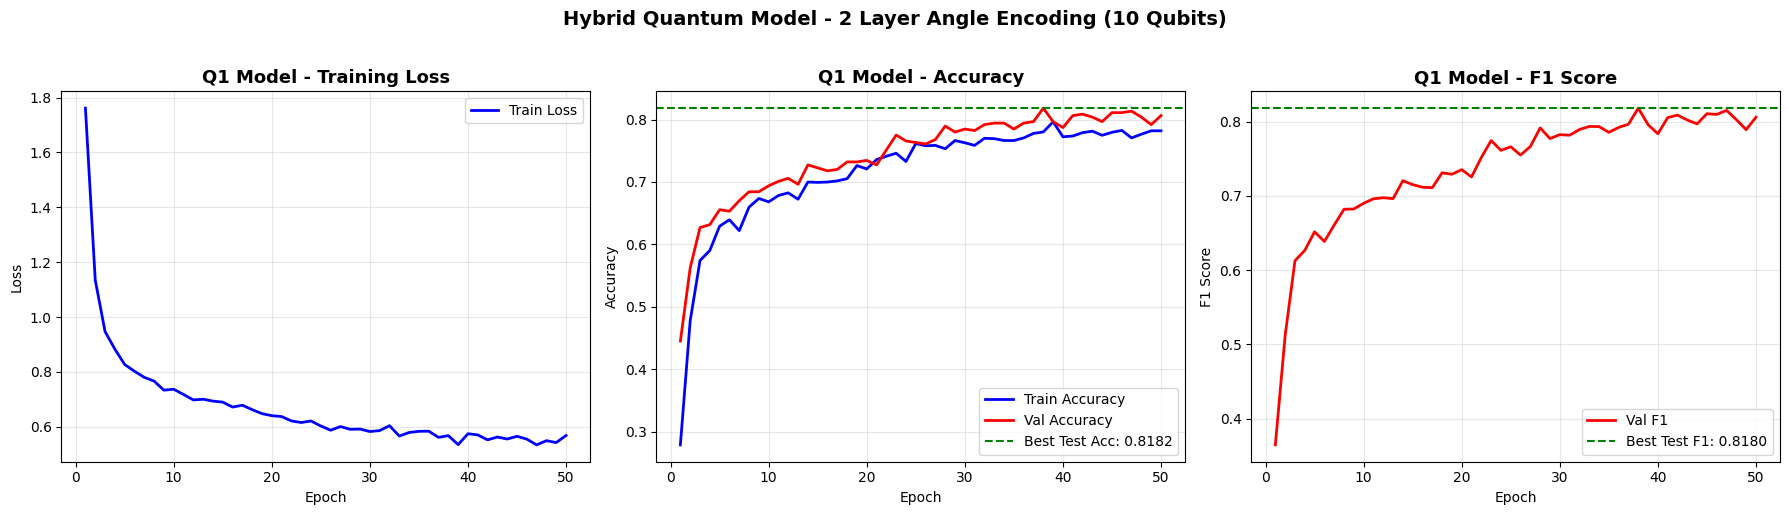

Grafik Drive'a kaydedildi!


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss
axes[0].plot(range(1, N_EPOCHS+1), train_losses, 'b-', linewidth=2, label='Train Loss')
axes[0].set_title('Q1 Model - Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy
axes[1].plot(range(1, N_EPOCHS+1), train_accs, 'b-', linewidth=2, label='Train Accuracy')
axes[1].plot(range(1, N_EPOCHS+1), val_accs, 'r-', linewidth=2, label='Val Accuracy')
axes[1].axhline(y=acc, color='g', linestyle='--', linewidth=1.5, label=f'Best Test Acc: {acc:.4f}')
axes[1].set_title('Q1 Model - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. F1
axes[2].plot(range(1, N_EPOCHS+1), val_f1s, 'r-', linewidth=2, label='Val F1')
axes[2].axhline(y=f1_w, color='g', linestyle='--', linewidth=1.5, label=f'Best Test F1: {f1_w:.4f}')
axes[2].set_title('Q1 Model - F1 Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Hybrid Quantum Model - 2 Layer Angle Encoding (10 Qubits)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Obesity_Quantum_Project/q1_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Grafik Drive'a kaydedildi!")

In [16]:
import pandas as pd
from collections import Counter

full_path = '/content/drive/MyDrive/Obesity_Quantum_Project/processed_data/obesity_top10_dataset.csv'

full_df = pd.read_csv(full_path)

print("FULL shape:", full_df.shape)
print("TRAIN shape:", train_df.shape)
print("TEST shape :", test_df.shape)
print("TRAIN + TEST =", len(train_df) + len(test_df))

total = len(train_df) + len(test_df)
print("\nOranlar:")
print(f"Train ratio: {len(train_df)/total:.4f} -> %{100*len(train_df)/total:.2f}")
print(f"Test ratio : {len(test_df)/total:.4f} -> %{100*len(test_df)/total:.2f}")

print("\nSütunlar aynı mı?")
print("Train-Test:", list(train_df.columns) == list(test_df.columns))
print("Train-Full:", set(train_df.columns) == set(full_df.columns))

# Train + Test tam olarak full dataset ediyor mu?
combined_df = pd.concat([train_df, test_df], ignore_index=True)

full_hash = Counter(pd.util.hash_pandas_object(full_df, index=False))
combined_hash = Counter(pd.util.hash_pandas_object(combined_df, index=False))

print("\nTrain+Test tam olarak Full dataset mi?")
print(full_hash == combined_hash)

# Train-test overlap kontrolü
train_hash = set(pd.util.hash_pandas_object(train_df, index=False))
test_hash = set(pd.util.hash_pandas_object(test_df, index=False))
overlap = len(train_hash.intersection(test_hash))

print("\nTrain/Test ortak satır sayısı:", overlap)

print("\nTrain class distribution (%):")
print((train_df['NObeyesdad'].value_counts(normalize=True) * 100).round(2).sort_index())

print("\nTest class distribution (%):")
print((test_df['NObeyesdad'].value_counts(normalize=True) * 100).round(2).sort_index())

FULL shape: (2087, 11)
TRAIN shape: (1669, 11)
TEST shape : (418, 11)
TRAIN + TEST = 2087

Oranlar:
Train ratio: 0.7997 -> %79.97
Test ratio : 0.2003 -> %20.03

Sütunlar aynı mı?
Train-Test: True
Train-Full: True

Train+Test tam olarak Full dataset mi?
True

Train/Test ortak satır sayısı: 1

Train class distribution (%):
NObeyesdad
Insufficient_Weight    12.82
Normal_Weight          13.48
Obesity_Type_I         16.84
Obesity_Type_II        14.20
Obesity_Type_III       15.52
Overweight_Level_I     13.24
Overweight_Level_II    13.90
Name: proportion, dtype: float64

Test class distribution (%):
NObeyesdad
Insufficient_Weight    12.68
Normal_Weight          13.64
Obesity_Type_I         16.75
Obesity_Type_II        14.35
Obesity_Type_III       15.55
Overweight_Level_I     13.16
Overweight_Level_II    13.88
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

# Train içinden validation ayır
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_angle,
    y_train_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train_enc
)

# Tensor'a çevir
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_te_tensor = torch.tensor(X_test_angle, dtype=torch.float32)

y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_te_tensor = torch.tensor(y_test_enc, dtype=torch.long)

# DataLoader
tr_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor),
                       batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor),
                        batch_size=32, shuffle=False)
te_loader = DataLoader(TensorDataset(X_te_tensor, y_te_tensor),
                       batch_size=32, shuffle=False)

print("Train (egitim) :", X_tr.shape)
print("Validation     :", X_val.shape)
print("Test (final)   :", X_test_angle.shape)
print()
print("Stratified mi kontrol et:")
import collections
print("Train class dist  :", dict(sorted(collections.Counter(y_tr).items())))
print("Val class dist    :", dict(sorted(collections.Counter(y_val).items())))
print("Test class dist   :", dict(sorted(collections.Counter(y_test_enc).items())))

Train (egitim) : (1335, 10)
Validation     : (334, 10)
Test (final)   : (418, 10)

Stratified mi kontrol et:
Train class dist  : {np.int64(0): 171, np.int64(1): 180, np.int64(2): 225, np.int64(3): 189, np.int64(4): 207, np.int64(5): 177, np.int64(6): 186}
Val class dist    : {np.int64(0): 43, np.int64(1): 45, np.int64(2): 56, np.int64(3): 48, np.int64(4): 52, np.int64(5): 44, np.int64(6): 46}
Test class dist   : {np.int64(0): 53, np.int64(1): 57, np.int64(2): 70, np.int64(3): 60, np.int64(4): 65, np.int64(5): 55, np.int64(6): 58}


In [18]:
import random
import time
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Modeli sifirdan kur
model_clean = HybridQuantumModel(N_QUBITS, N_LAYERS, N_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_clean.parameters(), lr=0.01)

# Kayitlar
clean_train_losses = []
clean_train_accs = []
clean_val_accs = []
clean_val_f1s = []

N_EPOCHS = 50
best_val_f1 = 0.0
best_epoch = 0
patience = 12
patience_counter = 0

print("Temiz egitim basliyor (Train/Val/Test ayri)...")
print("=" * 60)

start_time = time.time()

for epoch in range(N_EPOCHS):
    # ---- TRAIN ----
    model_clean.train()
    epoch_loss = 0.0
    train_preds = []
    train_labels = []

    for X_batch, y_batch in tr_loader:
        optimizer.zero_grad()
        outputs = model_clean(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(y_batch.detach().cpu().numpy())

    train_loss = epoch_loss / len(tr_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    # ---- VALIDATION ----
    model_clean.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_clean(X_batch)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.detach().cpu().numpy())
            val_labels.extend(y_batch.detach().cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    clean_train_losses.append(train_loss)
    clean_train_accs.append(train_acc)
    clean_val_accs.append(val_acc)
    clean_val_f1s.append(val_f1)

    # Best model save
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_clean.state_dict(), 'best_q1_clean.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Sure: {elapsed:.1f}s")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping tetiklendi. {epoch+1}. epoch'ta durdu.")
        break

print("=" * 60)
print(f"Temiz egitim tamamlandi!")
print(f"En iyi Validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
print(f"Toplam sure: {time.time() - start_time:.1f} saniye")

Temiz egitim basliyor (Train/Val/Test ayri)...
Epoch   5/50 | Loss: 0.8792 | Train Acc: 0.5948 | Val Acc: 0.6766 | Val F1: 0.6637 | Sure: 39.5s
Epoch  10/50 | Loss: 0.7309 | Train Acc: 0.6884 | Val Acc: 0.7305 | Val F1: 0.7102 | Sure: 73.0s
Epoch  15/50 | Loss: 0.6749 | Train Acc: 0.7079 | Val Acc: 0.7784 | Val F1: 0.7720 | Sure: 104.7s
Epoch  20/50 | Loss: 0.6430 | Train Acc: 0.7199 | Val Acc: 0.7994 | Val F1: 0.7936 | Sure: 137.3s
Epoch  25/50 | Loss: 0.5902 | Train Acc: 0.7521 | Val Acc: 0.7814 | Val F1: 0.7648 | Sure: 169.8s
Epoch  30/50 | Loss: 0.5986 | Train Acc: 0.7363 | Val Acc: 0.7994 | Val F1: 0.7915 | Sure: 202.9s
Epoch  35/50 | Loss: 0.5627 | Train Acc: 0.7603 | Val Acc: 0.8293 | Val F1: 0.8239 | Sure: 236.6s
Epoch  40/50 | Loss: 0.5618 | Train Acc: 0.7700 | Val Acc: 0.8413 | Val F1: 0.8380 | Sure: 268.6s
Epoch  45/50 | Loss: 0.5430 | Train Acc: 0.7783 | Val Acc: 0.8293 | Val F1: 0.8238 | Sure: 300.9s
Epoch  50/50 | Loss: 0.5395 | Train Acc: 0.7813 | Val Acc: 0.8353 | Val F

In [19]:
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              roc_auc_score, classification_report)

# En iyi modeli yukle
model_clean.load_state_dict(torch.load('best_q1_clean.pt'))
model_clean.eval()

# Test tahminleri
test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for X_batch, y_batch in te_loader:
        outputs = model_clean(X_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Metrikler
acc = accuracy_score(test_labels, test_preds)
f1_w = f1_score(test_labels, test_preds, average='weighted')
f1_mac = f1_score(test_labels, test_preds, average='macro')
prec = precision_score(test_labels, test_preds, average='weighted')
rec = recall_score(test_labels, test_preds, average='weighted')
roc_auc = roc_auc_score(test_labels, test_probs,
                         multi_class='ovr', average='weighted')

print("=" * 60)
print("Q1 FINAL TEST SONUCLARI")
print("2 Layer | Angle Encoding | 10 Qubit | Temiz Split")
print("=" * 60)
print(f"Accuracy        : {acc:.4f}")
print(f"F1 (weighted)   : {f1_w:.4f}")
print(f"F1 (macro)      : {f1_mac:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")
print("=" * 60)
print("\nDetayli Rapor:")
print(classification_report(test_labels, test_preds,
                             target_names=le.classes_))

Q1 FINAL TEST SONUCLARI
2 Layer | Angle Encoding | 10 Qubit | Temiz Split
Accuracy        : 0.7895
F1 (weighted)   : 0.7822
F1 (macro)      : 0.7769
Precision       : 0.7904
Recall          : 0.7895
ROC-AUC         : 0.9698

Detayli Rapor:
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.83      0.84        53
      Normal_Weight       0.69      0.79      0.74        57
     Obesity_Type_I       0.69      0.89      0.78        70
    Obesity_Type_II       0.88      1.00      0.94        60
   Obesity_Type_III       1.00      0.95      0.98        65
 Overweight_Level_I       0.61      0.45      0.52        55
Overweight_Level_II       0.80      0.55      0.65        58

           accuracy                           0.79       418
          macro avg       0.79      0.78      0.78       418
       weighted avg       0.79      0.79      0.78       418



In [20]:
# Q2 Model - 4 Layer
N_LAYERS_Q2 = 4

dev_q2 = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev_q2, interface='torch')
def quantum_circuit_q2(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    for layer in range(N_LAYERS_Q2):
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class HybridQuantumModelQ2(nn.Module):
    def __init__(self, n_qubits, n_layers, n_classes):
        super(HybridQuantumModelQ2, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        weight_shapes = {"weights": (n_layers, n_qubits, 2)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit_q2, weight_shapes)
        self.classical_head = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        quantum_out = self.qlayer(x)
        out = self.classical_head(quantum_out)
        return out

# Test et
model_q2 = HybridQuantumModelQ2(N_QUBITS, N_LAYERS_Q2, N_CLASSES)
test_input = torch.zeros(4, N_QUBITS)
test_output = model_q2(test_input)

total_params = sum(p.numel() for p in model_q2.parameters())
print("Q2 Model hazir!")
print("Output shape:", test_output.shape)
print("Toplam parametre:", total_params)

Q2 Model hazir!
Output shape: torch.Size([4, 7])
Toplam parametre: 375


In [21]:
import random
import time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model_q2 = HybridQuantumModelQ2(N_QUBITS, N_LAYERS_Q2, N_CLASSES)
criterion_q2 = nn.CrossEntropyLoss()
optimizer_q2 = torch.optim.Adam(model_q2.parameters(), lr=0.01)

q2_train_losses = []
q2_train_accs = []
q2_val_accs = []
q2_val_f1s = []

N_EPOCHS = 50
best_val_f1_q2 = 0.0
best_epoch_q2 = 0
patience = 12
patience_counter = 0

print("Q2 egitim basliyor (4 Layer)...")
print("=" * 60)

start_time = time.time()

for epoch in range(N_EPOCHS):
    model_q2.train()
    epoch_loss = 0.0
    train_preds = []
    train_labels = []

    for X_batch, y_batch in tr_loader:
        optimizer_q2.zero_grad()
        outputs = model_q2(X_batch)
        loss = criterion_q2(outputs, y_batch)
        loss.backward()
        optimizer_q2.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(y_batch.detach().cpu().numpy())

    train_loss = epoch_loss / len(tr_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    model_q2.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_q2(X_batch)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.detach().cpu().numpy())
            val_labels.extend(y_batch.detach().cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    q2_train_losses.append(train_loss)
    q2_train_accs.append(train_acc)
    q2_val_accs.append(val_acc)
    q2_val_f1s.append(val_f1)

    if val_f1 > best_val_f1_q2:
        best_val_f1_q2 = val_f1
        best_epoch_q2 = epoch + 1
        patience_counter = 0
        torch.save(model_q2.state_dict(), 'best_q2_clean.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Sure: {elapsed:.1f}s")

    if patience_counter >= patience:
        print(f"\nEarly stopping tetiklendi. Epoch {epoch+1}'de durdu.")
        break

print("=" * 60)
print(f"Q2 egitim tamamlandi!")
print(f"En iyi Validation F1: {best_val_f1_q2:.4f} (Epoch {best_epoch_q2})")
print(f"Toplam sure: {time.time() - start_time:.1f} saniye")

Q2 egitim basliyor (4 Layer)...
Epoch   5/50 | Loss: 1.3480 | Train Acc: 0.4419 | Val Acc: 0.4820 | Val F1: 0.3943 | Sure: 65.1s
Epoch  10/50 | Loss: 1.1147 | Train Acc: 0.5079 | Val Acc: 0.5778 | Val F1: 0.5423 | Sure: 122.2s
Epoch  15/50 | Loss: 0.9511 | Train Acc: 0.6000 | Val Acc: 0.6317 | Val F1: 0.6121 | Sure: 178.9s
Epoch  20/50 | Loss: 0.8596 | Train Acc: 0.6449 | Val Acc: 0.7066 | Val F1: 0.7008 | Sure: 242.6s
Epoch  25/50 | Loss: 0.7858 | Train Acc: 0.6959 | Val Acc: 0.7515 | Val F1: 0.7443 | Sure: 299.2s
Epoch  30/50 | Loss: 0.7497 | Train Acc: 0.6839 | Val Acc: 0.7305 | Val F1: 0.7217 | Sure: 354.7s
Epoch  35/50 | Loss: 0.6924 | Train Acc: 0.7161 | Val Acc: 0.7425 | Val F1: 0.7349 | Sure: 409.1s
Epoch  40/50 | Loss: 0.6646 | Train Acc: 0.7221 | Val Acc: 0.7784 | Val F1: 0.7754 | Sure: 465.3s
Epoch  45/50 | Loss: 0.6418 | Train Acc: 0.7371 | Val Acc: 0.8054 | Val F1: 0.8037 | Sure: 521.2s
Epoch  50/50 | Loss: 0.6240 | Train Acc: 0.7468 | Val Acc: 0.7844 | Val F1: 0.7857 | Su

In [22]:
model_q2.load_state_dict(torch.load('best_q2_clean.pt'))
model_q2.eval()

test_preds_q2 = []
test_labels_q2 = []
test_probs_q2 = []

with torch.no_grad():
    for X_batch, y_batch in te_loader:
        outputs = model_q2(X_batch)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        test_preds_q2.extend(preds.cpu().numpy())
        test_labels_q2.extend(y_batch.cpu().numpy())
        test_probs_q2.extend(probs.cpu().numpy())

test_preds_q2 = np.array(test_preds_q2)
test_labels_q2 = np.array(test_labels_q2)
test_probs_q2 = np.array(test_probs_q2)

acc_q2 = accuracy_score(test_labels_q2, test_preds_q2)
f1_w_q2 = f1_score(test_labels_q2, test_preds_q2, average='weighted')
f1_mac_q2 = f1_score(test_labels_q2, test_preds_q2, average='macro')
prec_q2 = precision_score(test_labels_q2, test_preds_q2, average='weighted')
rec_q2 = recall_score(test_labels_q2, test_preds_q2, average='weighted')
roc_auc_q2 = roc_auc_score(test_labels_q2, test_probs_q2,
                             multi_class='ovr', average='weighted')

print("=" * 60)
print("Q2 FINAL TEST SONUCLARI")
print("4 Layer | Angle Encoding | 10 Qubit | Temiz Split")
print("=" * 60)
print(f"Accuracy        : {acc_q2:.4f}")
print(f"F1 (weighted)   : {f1_w_q2:.4f}")
print(f"F1 (macro)      : {f1_mac_q2:.4f}")
print(f"Precision       : {prec_q2:.4f}")
print(f"Recall          : {rec_q2:.4f}")
print(f"ROC-AUC         : {roc_auc_q2:.4f}")
print("=" * 60)
print("\nDetayli Rapor:")
print(classification_report(test_labels_q2, test_preds_q2,
                             target_names=le.classes_))

Q2 FINAL TEST SONUCLARI
4 Layer | Angle Encoding | 10 Qubit | Temiz Split
Accuracy        : 0.7512
F1 (weighted)   : 0.7473
F1 (macro)      : 0.7389
Precision       : 0.7509
Recall          : 0.7512
ROC-AUC         : 0.9602

Detayli Rapor:
                     precision    recall  f1-score   support

Insufficient_Weight       0.70      0.91      0.79        53
      Normal_Weight       0.63      0.47      0.54        57
     Obesity_Type_I       0.78      0.84      0.81        70
    Obesity_Type_II       0.96      0.90      0.93        60
   Obesity_Type_III       1.00      0.97      0.98        65
 Overweight_Level_I       0.55      0.51      0.53        55
Overweight_Level_II       0.58      0.60      0.59        58

           accuracy                           0.75       418
          macro avg       0.74      0.74      0.74       418
       weighted avg       0.75      0.75      0.75       418



In [23]:
import os

base_dir = '/content/drive/MyDrive/Obesity_Quantum_Project'

print("BASE DIR:", base_dir)
print("\nUst klasor icerigi:")
for item in sorted(os.listdir(base_dir)):
    full_path = os.path.join(base_dir, item)
    tip = "KLASOR" if os.path.isdir(full_path) else "DOSYA"
    print(f"- {item} [{tip}]")

print("\n" + "="*60)
for sub in ['tables', 'figures', 'results', 'processed_data']:
    sub_path = os.path.join(base_dir, sub)
    if os.path.exists(sub_path):
        print(f"\n{sub_path} icerigi:")
        for item in sorted(os.listdir(sub_path)):
            print("  -", item)
    else:
        print(f"\n{sub_path} bulunamadi.")

BASE DIR: /content/drive/MyDrive/Obesity_Quantum_Project

Ust klasor icerigi:
- data [KLASOR]
- figures [KLASOR]
- notebooks [KLASOR]
- notes [KLASOR]
- processed_data [KLASOR]
- q1_training_curves.png [DOSYA]
- quantum_compact6 [KLASOR]
- quantum_figures [KLASOR]
- quantum_notes [KLASOR]
- quantum_results [KLASOR]
- quantum_tables [KLASOR]
- results [KLASOR]
- tables [KLASOR]


/content/drive/MyDrive/Obesity_Quantum_Project/tables icerigi:
  - cv_summary_top_models.csv
  - final_classical_model_comparison.csv
  - final_classical_model_comparison_with_xgb.csv
  - model_comparison_initial.csv
  - model_comparison_with_f1.csv
  - model_comparison_with_f1_rounded.csv
  - original_feature_importance.csv
  - package_versions.csv
  - xgb_10_permutation_importance.csv
  - xgb_16_feature_importance.csv
  - xgb_16_original_feature_importance.csv

/content/drive/MyDrive/Obesity_Quantum_Project/figures icerigi:
  - class_distribution.png
  - cv_summary_top_models.png
  - final_classical_model_com

In [24]:
import pandas as pd
import os

classical_csv_path = '/content/drive/MyDrive/Obesity_Quantum_Project/tables/final_classical_model_comparison_with_xgb.csv'

print("Dosya var mi?", os.path.exists(classical_csv_path))

classical_df = pd.read_csv(classical_csv_path)

print("\nShape:", classical_df.shape)
print("\nColumns:")
print(classical_df.columns.tolist())

print("\nTam tablo:")
print(classical_df)

print("\nData types:")
print(classical_df.dtypes)

Dosya var mi? True

Shape: (6, 4)

Columns:
['Model', 'Accuracy', 'Macro F1', 'Weighted F1']

Tam tablo:
                              Model  Accuracy  Macro F1  Weighted F1
0  Logistic Regression (16 özellik)    0.8971    0.8928       0.8954
1        Random Forest (16 özellik)    0.9450    0.9440       0.9461
2              XGBoost (16 özellik)    0.9689    0.9678       0.9688
3  Logistic Regression (10 özellik)    0.8852    0.8795       0.8843
4        Random Forest (10 özellik)    0.9402    0.9381       0.9411
5              XGBoost (10 özellik)    0.9689    0.9681       0.9688

Data types:
Model           object
Accuracy       float64
Macro F1       float64
Weighted F1    float64
dtype: object


In [25]:
import os

base_dir = '/content/drive/MyDrive/Obesity_Quantum_Project'
exp_dir = os.path.join(base_dir, 'quantum_clean_top10_angle')

fig_dir = os.path.join(exp_dir, 'figures')
tab_dir = os.path.join(exp_dir, 'tables')
model_dir = os.path.join(exp_dir, 'models')
note_dir = os.path.join(exp_dir, 'notes')

for d in [exp_dir, fig_dir, tab_dir, model_dir, note_dir]:
    os.makedirs(d, exist_ok=True)

print("Olusturulan klasorler:")
print("exp_dir  :", exp_dir)
print("fig_dir  :", fig_dir)
print("tab_dir  :", tab_dir)
print("model_dir:", model_dir)
print("note_dir :", note_dir)

Olusturulan klasorler:
exp_dir  : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle
fig_dir  : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/figures
tab_dir  : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/tables
model_dir: /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/models
note_dir : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/notes


In [26]:
import os
import json
import shutil
import joblib
import pandas as pd
import numpy as np

# Parametre sayilari
q1_params = sum(p.numel() for p in model_clean.parameters())
q2_params = sum(p.numel() for p in model_q2.parameters())

# Model dosyalarini Drive'a kopyala
if os.path.exists('best_q1_clean.pt'):
    shutil.copy('best_q1_clean.pt', os.path.join(model_dir, 'best_q1_clean.pt'))

if os.path.exists('best_q2_clean.pt'):
    shutil.copy('best_q2_clean.pt', os.path.join(model_dir, 'best_q2_clean.pt'))

# Scaler ve label encoder kaydet
joblib.dump(scaler, os.path.join(model_dir, 'standard_scaler.pkl'))
joblib.dump(le, os.path.join(model_dir, 'label_encoder.pkl'))

# Feature listesi kaydet
feature_names = X_train.columns.tolist()
pd.DataFrame({'Feature': feature_names}).to_csv(
    os.path.join(tab_dir, 'top10_feature_names_used_in_quantum.csv'),
    index=False
)

# Class mapping
class_mapping = {int(i): cls for i, cls in enumerate(le.classes_)}

# Metadata
metadata = {
    "experiment_name": "quantum_clean_top10_angle",
    "dataset": {
        "full_dataset_file": "obesity_top10_dataset.csv",
        "train_file": "train_10_features.csv",
        "test_file": "test_10_features.csv",
        "n_total_samples": 2087,
        "n_features": 10,
        "feature_names": feature_names,
        "n_classes": 7,
        "class_names": list(le.classes_),
        "class_mapping": class_mapping
    },
    "splits": {
        "original_ready_split": {
            "train": 1669,
            "test": 418,
            "train_ratio": 1669 / 2087,
            "test_ratio": 418 / 2087
        },
        "clean_experiment_split": {
            "train": 1335,
            "validation": 334,
            "test": 418,
            "train_ratio": 1335 / 2087,
            "validation_ratio": 334 / 2087,
            "test_ratio": 418 / 2087
        },
        "note": "Train/test split hazır dosyalardan alındı; final deney için train verisi içinden stratified validation ayrıldı."
    },
    "preprocessing": {
        "categorical_encoding": {
            "Gender": {"Male": 1, "Female": 0},
            "CALC": {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
            "family_history_with_overweight": {"yes": 1, "no": 0}
        },
        "target_encoding": class_mapping,
        "scaling": "StandardScaler",
        "angle_mapping": "clip[-3, 3] * (pi / 3)"
    },
    "models": {
        "Q1": {
            "description": "Hybrid Quantum Q1",
            "qubits": 10,
            "layers": 2,
            "encoding": "AngleEmbedding (RY)",
            "entanglement": "Ring CNOT",
            "all_qubit_readout": True,
            "classical_head": "Linear(10,16) + ReLU + Dropout(0.2) + Linear(16,7)",
            "params": int(q1_params),
            "best_val_f1": float(best_val_f1),
            "best_epoch": int(best_epoch),
            "test_accuracy": float(acc),
            "test_macro_f1": float(f1_mac),
            "test_weighted_f1": float(f1_w),
            "test_precision": float(prec),
            "test_recall": float(rec),
            "test_roc_auc": float(roc_auc)
        },
        "Q2": {
            "description": "Hybrid Quantum Q2",
            "qubits": 10,
            "layers": 4,
            "encoding": "AngleEmbedding (RY)",
            "entanglement": "Ring CNOT",
            "all_qubit_readout": True,
            "classical_head": "Linear(10,16) + ReLU + Dropout(0.2) + Linear(16,7)",
            "params": int(q2_params),
            "best_val_f1": float(best_val_f1_q2),
            "best_epoch": int(best_epoch_q2),
            "test_accuracy": float(acc_q2),
            "test_macro_f1": float(f1_mac_q2),
            "test_weighted_f1": float(f1_w_q2),
            "test_precision": float(prec_q2),
            "test_recall": float(rec_q2),
            "test_roc_auc": float(roc_auc_q2)
        }
    },
    "data_integrity_checks": {
        "train_plus_test_equals_full": True,
        "train_test_overlap_rows_detected": 1,
        "comment": "Hazır split dosyalarında 1 ortak satır tespit edildi; klasik modellerle adil karşılaştırma için aynı split korunmuştur."
    }
}

with open(os.path.join(note_dir, 'experiment_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Kaydedilenler:")
print("- best_q1_clean.pt")
print("- best_q2_clean.pt")
print("- standard_scaler.pkl")
print("- label_encoder.pkl")
print("- top10_feature_names_used_in_quantum.csv")
print("- experiment_metadata.json")

Kaydedilenler:
- best_q1_clean.pt
- best_q2_clean.pt
- standard_scaler.pkl
- label_encoder.pkl
- top10_feature_names_used_in_quantum.csv
- experiment_metadata.json


In [27]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Quantum özet tablo
quantum_summary_df = pd.DataFrame([
    {
        "Model": "Hybrid Quantum Q1 (10 özellik, 2 layer)",
        "Qubits": 10,
        "Layers": 2,
        "Encoding": "Angle",
        "Accuracy": acc,
        "Macro F1": f1_mac,
        "Weighted F1": f1_w,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": roc_auc,
        "Best Val F1": best_val_f1,
        "Best Epoch": best_epoch,
        "Parameters": q1_params
    },
    {
        "Model": "Hybrid Quantum Q2 (10 özellik, 4 layer)",
        "Qubits": 10,
        "Layers": 4,
        "Encoding": "Angle",
        "Accuracy": acc_q2,
        "Macro F1": f1_mac_q2,
        "Weighted F1": f1_w_q2,
        "Precision": prec_q2,
        "Recall": rec_q2,
        "ROC-AUC": roc_auc_q2,
        "Best Val F1": best_val_f1_q2,
        "Best Epoch": best_epoch_q2,
        "Parameters": q2_params
    }
])

quantum_summary_path = os.path.join(tab_dir, 'quantum_clean_model_summary.csv')
quantum_summary_df.to_csv(quantum_summary_path, index=False)

# Training history
q1_history_df = pd.DataFrame({
    "Epoch": np.arange(1, len(clean_train_losses) + 1),
    "Train Loss": clean_train_losses,
    "Train Accuracy": clean_train_accs,
    "Validation Accuracy": clean_val_accs,
    "Validation Weighted F1": clean_val_f1s
})
q1_history_df.to_csv(os.path.join(tab_dir, 'q1_training_history.csv'), index=False)

q2_history_df = pd.DataFrame({
    "Epoch": np.arange(1, len(q2_train_losses) + 1),
    "Train Loss": q2_train_losses,
    "Train Accuracy": q2_train_accs,
    "Validation Accuracy": q2_val_accs,
    "Validation Weighted F1": q2_val_f1s
})
q2_history_df.to_csv(os.path.join(tab_dir, 'q2_training_history.csv'), index=False)

# Classification report'lar
q1_report_df = pd.DataFrame(
    classification_report(test_labels, test_preds, target_names=le.classes_, output_dict=True)
).T
q2_report_df = pd.DataFrame(
    classification_report(test_labels_q2, test_preds_q2, target_names=le.classes_, output_dict=True)
).T

q1_report_df.to_csv(os.path.join(tab_dir, 'q1_classification_report.csv'))
q2_report_df.to_csv(os.path.join(tab_dir, 'q2_classification_report.csv'))

# Confusion matrix CSV
cm_q1 = confusion_matrix(test_labels, test_preds)
cm_q2 = confusion_matrix(test_labels_q2, test_preds_q2)

cm_q1_df = pd.DataFrame(cm_q1, index=le.classes_, columns=le.classes_)
cm_q2_df = pd.DataFrame(cm_q2, index=le.classes_, columns=le.classes_)

cm_q1_df.to_csv(os.path.join(tab_dir, 'q1_confusion_matrix.csv'))
cm_q2_df.to_csv(os.path.join(tab_dir, 'q2_confusion_matrix.csv'))

# Test prediction dosyasi
predictions_df = pd.DataFrame({
    "true_label_id": test_labels,
    "true_label_name": le.inverse_transform(test_labels),
    "q1_pred_id": test_preds,
    "q1_pred_name": le.inverse_transform(test_preds),
    "q2_pred_id": test_preds_q2,
    "q2_pred_name": le.inverse_transform(test_preds_q2)
})
predictions_df.to_csv(os.path.join(tab_dir, 'q1_q2_test_predictions.csv'), index=False)

print("Kaydedildi:")
print("- quantum_clean_model_summary.csv")
print("- q1_training_history.csv")
print("- q2_training_history.csv")
print("- q1_classification_report.csv")
print("- q2_classification_report.csv")
print("- q1_confusion_matrix.csv")
print("- q2_confusion_matrix.csv")
print("- q1_q2_test_predictions.csv")
print("\nQuantum özet tablo:")
print(quantum_summary_df.round(4))

Kaydedildi:
- quantum_clean_model_summary.csv
- q1_training_history.csv
- q2_training_history.csv
- q1_classification_report.csv
- q2_classification_report.csv
- q1_confusion_matrix.csv
- q2_confusion_matrix.csv
- q1_q2_test_predictions.csv

Quantum özet tablo:
                                     Model  Qubits  Layers Encoding  Accuracy  \
0  Hybrid Quantum Q1 (10 özellik, 2 layer)      10       2    Angle    0.7895   
1  Hybrid Quantum Q2 (10 özellik, 4 layer)      10       4    Angle    0.7512   

   Macro F1  Weighted F1  Precision  Recall  ROC-AUC  Best Val F1  Best Epoch  \
0    0.7769       0.7822     0.7904  0.7895   0.9698       0.8448          48   
1    0.7389       0.7473     0.7509  0.7512   0.9602       0.8037          45   

   Parameters  
0         335  
1         375  


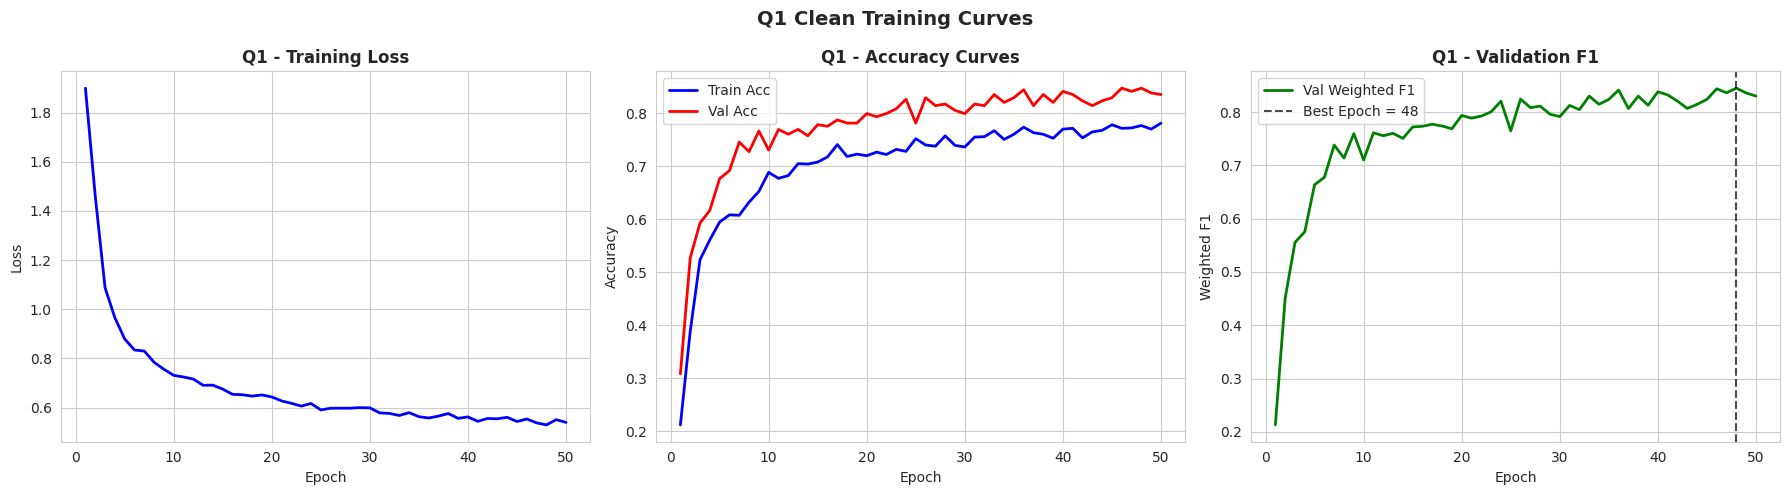

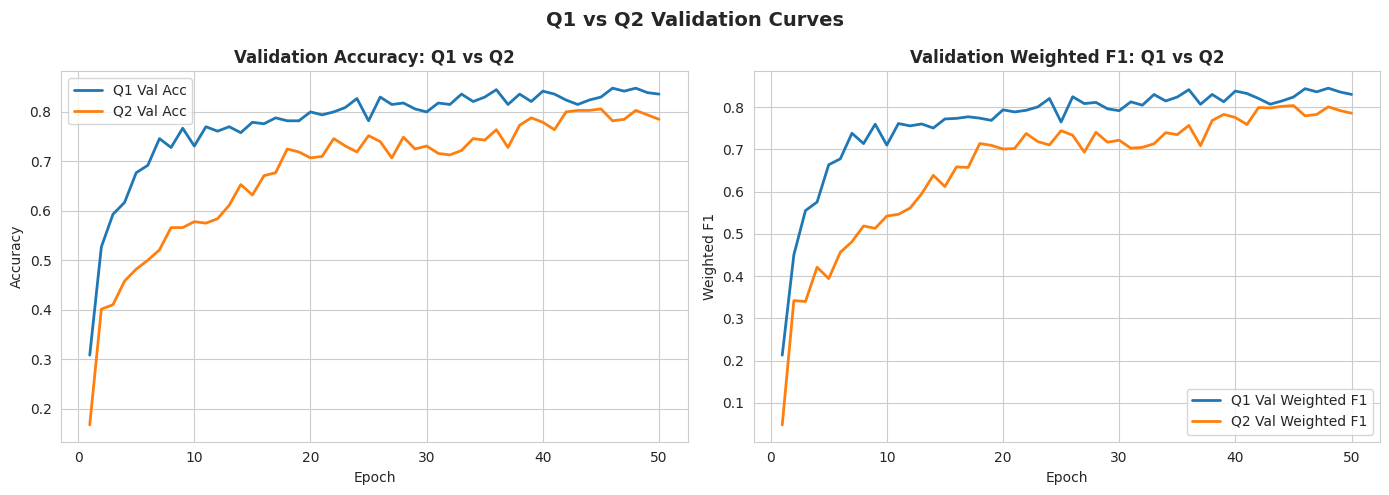

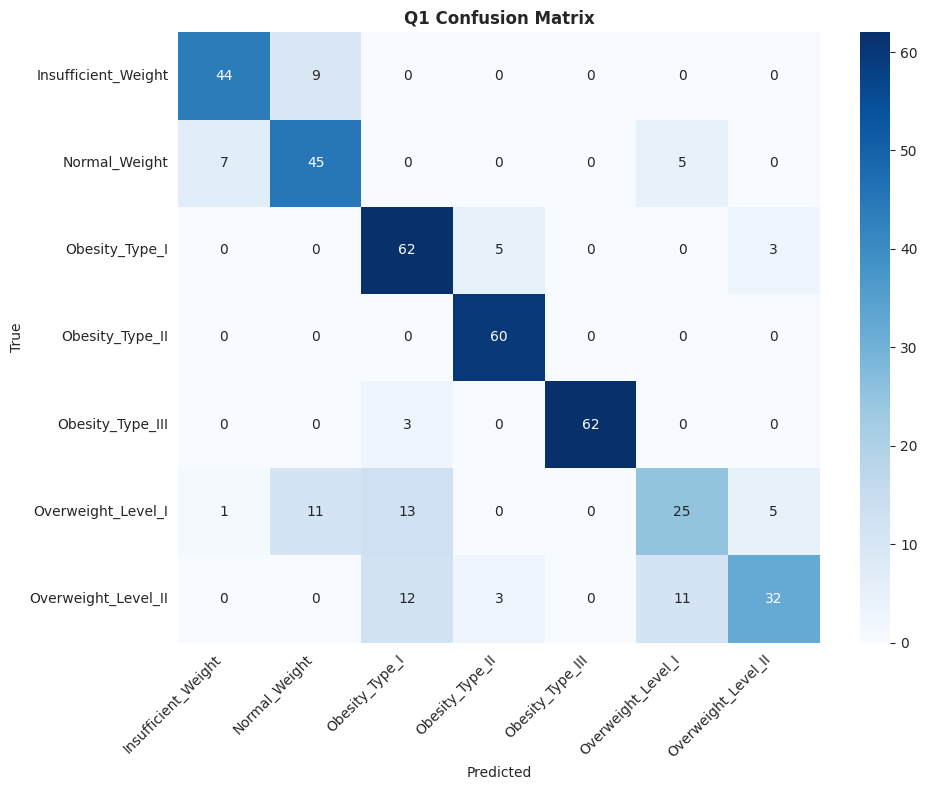

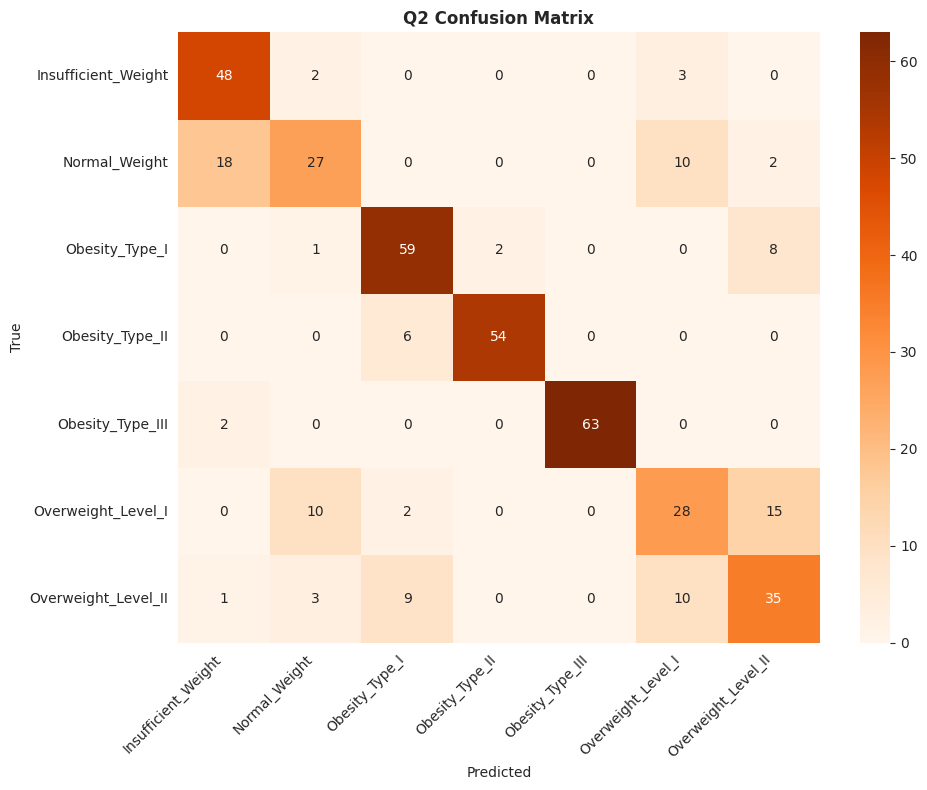

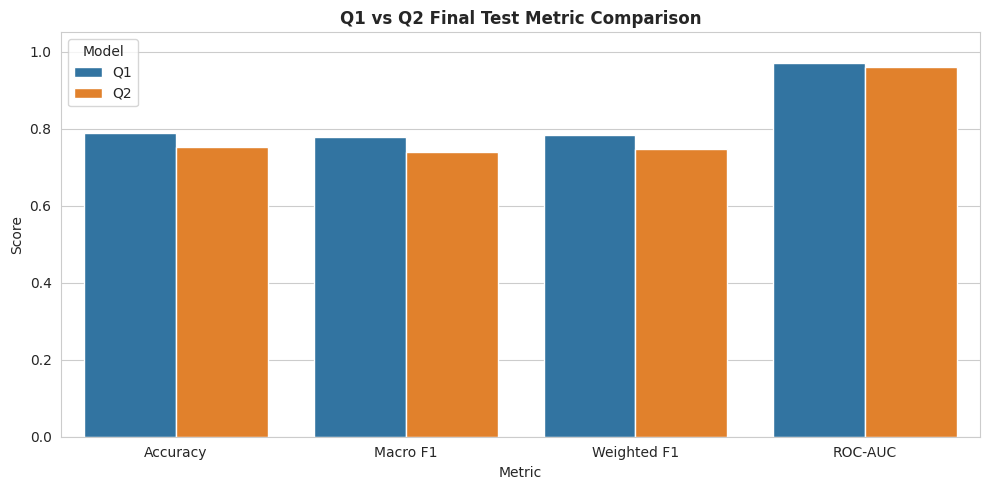

Quantum figürleri kaydedildi.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1) Q1 clean training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, len(clean_train_losses)+1), clean_train_losses, color='blue', linewidth=2)
axes[0].set_title('Q1 - Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(range(1, len(clean_train_accs)+1), clean_train_accs, label='Train Acc', color='blue', linewidth=2)
axes[1].plot(range(1, len(clean_val_accs)+1), clean_val_accs, label='Val Acc', color='red', linewidth=2)
axes[1].set_title('Q1 - Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(range(1, len(clean_val_f1s)+1), clean_val_f1s, label='Val Weighted F1', color='green', linewidth=2)
axes[2].axvline(best_epoch, color='black', linestyle='--', alpha=0.7, label=f'Best Epoch = {best_epoch}')
axes[2].set_title('Q1 - Validation F1', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Weighted F1')
axes[2].legend()

plt.suptitle('Q1 Clean Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'q1_clean_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# 2) Q1 vs Q2 validation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(clean_val_accs)+1), clean_val_accs, label='Q1 Val Acc', linewidth=2)
axes[0].plot(range(1, len(q2_val_accs)+1), q2_val_accs, label='Q2 Val Acc', linewidth=2)
axes[0].set_title('Validation Accuracy: Q1 vs Q2', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(range(1, len(clean_val_f1s)+1), clean_val_f1s, label='Q1 Val Weighted F1', linewidth=2)
axes[1].plot(range(1, len(q2_val_f1s)+1), q2_val_f1s, label='Q2 Val Weighted F1', linewidth=2)
axes[1].set_title('Validation Weighted F1: Q1 vs Q2', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].legend()

plt.suptitle('Q1 vs Q2 Validation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'q1_vs_q2_validation_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# 3) Confusion matrix - Q1
plt.figure(figsize=(10, 8))
sns.heatmap(cm_q1_df, annot=True, fmt='d', cmap='Blues')
plt.title('Q1 Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'q1_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# 4) Confusion matrix - Q2
plt.figure(figsize=(10, 8))
sns.heatmap(cm_q2_df, annot=True, fmt='d', cmap='Oranges')
plt.title('Q2 Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'q2_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# 5) Q1 vs Q2 test metric barplot
metric_compare_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC"],
    "Q1": [acc, f1_mac, f1_w, roc_auc],
    "Q2": [acc_q2, f1_mac_q2, f1_w_q2, roc_auc_q2]
})

plot_df = metric_compare_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title('Q1 vs Q2 Final Test Metric Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'q1_q2_test_metric_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

print("Quantum figürleri kaydedildi.")

In [29]:
import pandas as pd

classical_csv_path = '/content/drive/MyDrive/Obesity_Quantum_Project/tables/final_classical_model_comparison_with_xgb.csv'
classical_df = pd.read_csv(classical_csv_path)

# Quantum'u klasik tablo formatına uygun hazırla
quantum_compact_df = pd.DataFrame([
    {
        "Model": "Hybrid Quantum Q1 (10 özellik)",
        "Accuracy": acc,
        "Macro F1": f1_mac,
        "Weighted F1": f1_w
    },
    {
        "Model": "Hybrid Quantum Q2 (10 özellik)",
        "Accuracy": acc_q2,
        "Macro F1": f1_mac_q2,
        "Weighted F1": f1_w_q2
    }
])

# Adil karşılaştırma: sadece 10 özellikli klasik modeller + quantum
classical_top10_df = classical_df[classical_df['Model'].str.contains(r'\(10 özellik\)', regex=True)].copy()
fair_top10_df = pd.concat([classical_top10_df, quantum_compact_df], ignore_index=True)
fair_top10_df_sorted = fair_top10_df.sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)

# Tam karşılaştırma: tüm klasik + quantum
full_classical_quantum_df = pd.concat([classical_df, quantum_compact_df], ignore_index=True)
full_classical_quantum_df_sorted = full_classical_quantum_df.sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)

# Kaydet
fair_csv_path = os.path.join(tab_dir, 'fair_top10_classical_vs_quantum.csv')
full_csv_path = os.path.join(tab_dir, 'full_classical_quantum_comparison.csv')

fair_top10_df_sorted.to_csv(fair_csv_path, index=False)
full_classical_quantum_df_sorted.to_csv(full_csv_path, index=False)

print("Kaydedildi:")
print("-", fair_csv_path)
print("-", full_csv_path)

print("\nAdil karşılaştırma tablosu:")
print(fair_top10_df_sorted.round(4))

print("\nTam karşılaştırma tablosu:")
print(full_classical_quantum_df_sorted.round(4))

Kaydedildi:
- /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/tables/fair_top10_classical_vs_quantum.csv
- /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/tables/full_classical_quantum_comparison.csv

Adil karşılaştırma tablosu:
                              Model  Accuracy  Macro F1  Weighted F1
0              XGBoost (10 özellik)    0.9689    0.9681       0.9688
1        Random Forest (10 özellik)    0.9402    0.9381       0.9411
2  Logistic Regression (10 özellik)    0.8852    0.8795       0.8843
3    Hybrid Quantum Q1 (10 özellik)    0.7895    0.7769       0.7822
4    Hybrid Quantum Q2 (10 özellik)    0.7512    0.7389       0.7473

Tam karşılaştırma tablosu:
                              Model  Accuracy  Macro F1  Weighted F1
0              XGBoost (16 özellik)    0.9689    0.9678       0.9688
1              XGBoost (10 özellik)    0.9689    0.9681       0.9688
2        Random Forest (16 özellik)    0.9450    0.9440       0.9461
3  

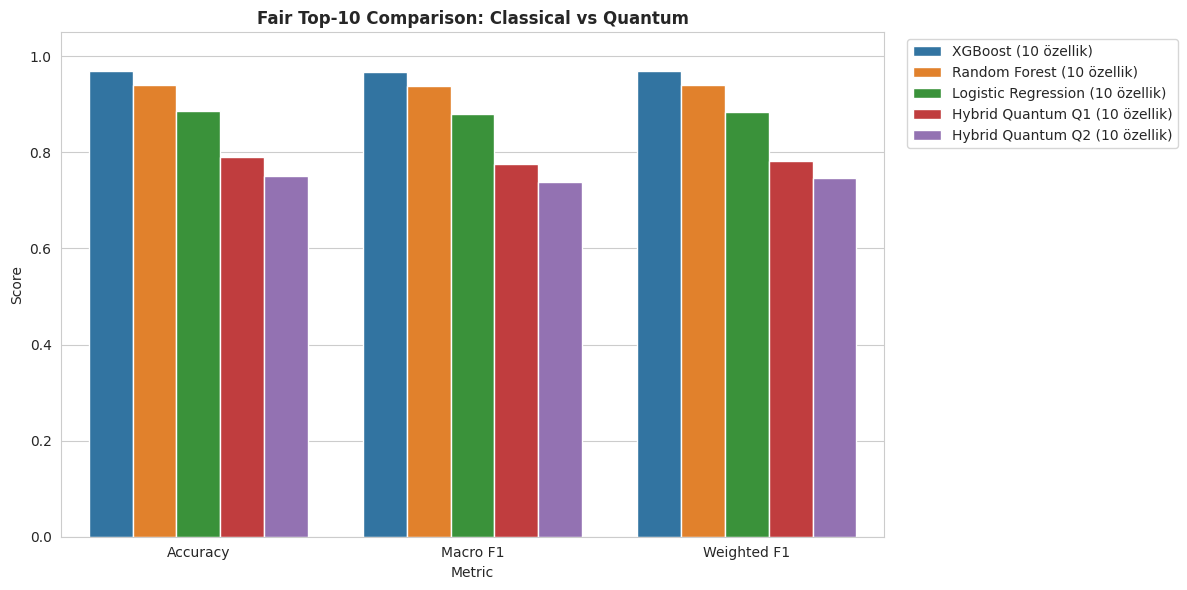

Kaydedildi:
- /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/figures/fair_top10_classical_vs_quantum_table.png
- /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/figures/full_classical_quantum_comparison_table.png
- /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/figures/fair_top10_classical_vs_quantum_barplot.png


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def save_dataframe_as_image(df, title, save_path):
    df_show = df.copy()
    for col in df_show.columns:
        if pd.api.types.is_float_dtype(df_show[col]):
            df_show[col] = df_show[col].map(lambda x: f"{x:.4f}")

    fig_width = max(10, len(df_show.columns) * 2.2)
    fig_height = max(2.5, len(df_show) * 0.6 + 1.5)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(title, fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()

# Tablo görselleri
fair_table_png = os.path.join(fig_dir, 'fair_top10_classical_vs_quantum_table.png')
full_table_png = os.path.join(fig_dir, 'full_classical_quantum_comparison_table.png')

save_dataframe_as_image(
    fair_top10_df_sorted,
    'Fair Comparison: Top-10 Classical vs Quantum',
    fair_table_png
)

save_dataframe_as_image(
    full_classical_quantum_df_sorted,
    'Full Classical + Quantum Comparison',
    full_table_png
)

# Adil karşılaştırma barplot
fair_plot_df = fair_top10_df_sorted.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Macro F1', 'Weighted F1'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=fair_plot_df, x='Metric', y='Score', hue='Model')
plt.ylim(0, 1.05)
plt.title('Fair Top-10 Comparison: Classical vs Quantum', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'fair_top10_classical_vs_quantum_barplot.png'), dpi=200, bbox_inches='tight')
plt.show()

print("Kaydedildi:")
print("-", fair_table_png)
print("-", full_table_png)
print("-", os.path.join(fig_dir, 'fair_top10_classical_vs_quantum_barplot.png'))

In [31]:
import shutil
import os

main_tables_dir = os.path.join(base_dir, 'tables')
main_figures_dir = os.path.join(base_dir, 'figures')

files_to_copy = [
    (os.path.join(tab_dir, 'quantum_clean_model_summary.csv'),
     os.path.join(main_tables_dir, 'quantum_clean_model_summary.csv')),

    (os.path.join(tab_dir, 'fair_top10_classical_vs_quantum.csv'),
     os.path.join(main_tables_dir, 'fair_top10_classical_vs_quantum.csv')),

    (os.path.join(tab_dir, 'full_classical_quantum_comparison.csv'),
     os.path.join(main_tables_dir, 'full_classical_quantum_comparison.csv')),

    (os.path.join(fig_dir, 'fair_top10_classical_vs_quantum_table.png'),
     os.path.join(main_figures_dir, 'fair_top10_classical_vs_quantum_table.png')),

    (os.path.join(fig_dir, 'full_classical_quantum_comparison_table.png'),
     os.path.join(main_figures_dir, 'full_classical_quantum_comparison_table.png')),

    (os.path.join(fig_dir, 'fair_top10_classical_vs_quantum_barplot.png'),
     os.path.join(main_figures_dir, 'fair_top10_classical_vs_quantum_barplot.png')),

    (os.path.join(fig_dir, 'q1_confusion_matrix.png'),
     os.path.join(main_figures_dir, 'q1_confusion_matrix.png')),

    (os.path.join(fig_dir, 'q2_confusion_matrix.png'),
     os.path.join(main_figures_dir, 'q2_confusion_matrix.png')),

    (os.path.join(fig_dir, 'q1_q2_test_metric_comparison.png'),
     os.path.join(main_figures_dir, 'q1_q2_test_metric_comparison.png'))
]

for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, dst)

print("Ana tables/figures klasorlerine kopyalama tamamlandi.")

Ana tables/figures klasorlerine kopyalama tamamlandi.


In [32]:
summary_text = f"""
EXPERIMENT SUMMARY
==================

Experiment Name:
quantum_clean_top10_angle

Dataset:
- Full dataset: obesity_top10_dataset.csv
- Train file: train_10_features.csv
- Test file : test_10_features.csv
- Features used: all selected top-10 features
- Number of classes: 7

Split Strategy:
- Ready train/test split from processed_data was used
- Original split: 1669 train / 418 test (~80/20)
- Clean experiment:
    * Train: 1335
    * Validation: 334
    * Test: 418
- Validation split was obtained from the train file using stratified split
- Note: 1 overlapping row was detected between provided train/test files; same split was preserved for fairness with classical baselines

Preprocessing:
- Gender encoded as Male=1, Female=0
- CALC encoded as no=0, Sometimes=1, Frequently=2, Always=3
- family_history_with_overweight encoded as yes=1, no=0
- StandardScaler applied
- Quantum angle mapping: clip[-3,3] * (pi/3)

Quantum Models:
Q1:
- 10 qubits
- Angle encoding
- 2 variational layers
- Ring CNOT entanglement
- All-qubit readout
- Small classical head
- Final Test Accuracy: {acc:.4f}
- Final Test Macro F1: {f1_mac:.4f}
- Final Test Weighted F1: {f1_w:.4f}
- Final Test ROC-AUC: {roc_auc:.4f}
- Best Validation F1: {best_val_f1:.4f} at epoch {best_epoch}

Q2:
- 10 qubits
- Angle encoding
- 4 variational layers
- Ring CNOT entanglement
- All-qubit readout
- Small classical head
- Final Test Accuracy: {acc_q2:.4f}
- Final Test Macro F1: {f1_mac_q2:.4f}
- Final Test Weighted F1: {f1_w_q2:.4f}
- Final Test ROC-AUC: {roc_auc_q2:.4f}
- Best Validation F1: {best_val_f1_q2:.4f} at epoch {best_epoch_q2}

Main Finding:
- Q1 outperformed Q2 on all final test metrics
- Increasing quantum circuit depth from 2 to 4 layers did not improve performance
- Shallow hybrid quantum architecture was more effective and more stable in this setting

Fair Comparison with Top-10 Classical Models:
- Logistic Regression (10 features): Accuracy=0.8852, Macro F1=0.8795, Weighted F1=0.8843
- Random Forest (10 features): Accuracy=0.9402, Macro F1=0.9381, Weighted F1=0.9411
- XGBoost (10 features): Accuracy=0.9689, Macro F1=0.9681, Weighted F1=0.9688
- Hybrid Quantum Q1 (10 features): Accuracy={acc:.4f}, Macro F1={f1_mac:.4f}, Weighted F1={f1_w:.4f}
- Hybrid Quantum Q2 (10 features): Accuracy={acc_q2:.4f}, Macro F1={f1_mac_q2:.4f}, Weighted F1={f1_w_q2:.4f}

Interpretation:
- Classical models still outperform the tested quantum models on this dataset
- However, the clean quantum experiment provides a controlled and fair evaluation
- The main quantum contribution is methodological:
  * exact top-10 feature usage
  * 10 qubits = 10 features mapping
  * pure angle encoding
  * controlled depth comparison (2 vs 4 layers)
"""

summary_path = os.path.join(note_dir, 'experiment_summary.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print("Kaydedildi:", summary_path)
print("\n--- OZET ---\n")
print(summary_text[:2500])

Kaydedildi: /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/notes/experiment_summary.txt

--- OZET ---


EXPERIMENT SUMMARY

Experiment Name:
quantum_clean_top10_angle

Dataset:
- Full dataset: obesity_top10_dataset.csv
- Train file: train_10_features.csv
- Test file : test_10_features.csv
- Features used: all selected top-10 features
- Number of classes: 7

Split Strategy:
- Ready train/test split from processed_data was used
- Original split: 1669 train / 418 test (~80/20)
- Clean experiment:
    * Train: 1335
    * Validation: 334
    * Test: 418
- Validation split was obtained from the train file using stratified split
- Note: 1 overlapping row was detected between provided train/test files; same split was preserved for fairness with classical baselines

Preprocessing:
- Gender encoded as Male=1, Female=0
- CALC encoded as no=0, Sometimes=1, Frequently=2, Always=3
- family_history_with_overweight encoded as yes=1, no=0
- StandardScaler applied
- Quantum ang

In [33]:
print("Deney klasoru kontrol:")
for sub in [fig_dir, tab_dir, model_dir, note_dir]:
    print("\n", sub)
    for item in sorted(os.listdir(sub)):
        print(" -", item)

Deney klasoru kontrol:

 /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/figures
 - fair_top10_classical_vs_quantum_barplot.png
 - fair_top10_classical_vs_quantum_table.png
 - full_classical_quantum_comparison_table.png
 - q1_clean_training_curves.png
 - q1_confusion_matrix.png
 - q1_q2_test_metric_comparison.png
 - q1_vs_q2_validation_curves.png
 - q2_confusion_matrix.png

 /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/tables
 - fair_top10_classical_vs_quantum.csv
 - full_classical_quantum_comparison.csv
 - q1_classification_report.csv
 - q1_confusion_matrix.csv
 - q1_q2_test_predictions.csv
 - q1_training_history.csv
 - q2_classification_report.csv
 - q2_confusion_matrix.csv
 - q2_training_history.csv
 - quantum_clean_model_summary.csv
 - top10_feature_names_used_in_quantum.csv

 /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_angle/models
 - best_q1_clean.pt
 - best_q2_clean.pt
 - label_encoder.pkl
 - standard_sc

In [34]:
import os

base_dir = '/content/drive/MyDrive/Obesity_Quantum_Project'
q3_dir = os.path.join(base_dir, 'quantum_clean_top10_hybrid_encoding')

q3_fig_dir = os.path.join(q3_dir, 'figures')
q3_tab_dir = os.path.join(q3_dir, 'tables')
q3_model_dir = os.path.join(q3_dir, 'models')
q3_note_dir = os.path.join(q3_dir, 'notes')

for d in [q3_dir, q3_fig_dir, q3_tab_dir, q3_model_dir, q3_note_dir]:
    os.makedirs(d, exist_ok=True)

print("Q3 klasorleri olusturuldu:")
print("- figures :", q3_fig_dir)
print("- tables  :", q3_tab_dir)
print("- models  :", q3_model_dir)
print("- notes   :", q3_note_dir)

Q3 klasorleri olusturuldu:
- figures : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_hybrid_encoding/figures
- tables  : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_hybrid_encoding/tables
- models  : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_hybrid_encoding/models
- notes   : /content/drive/MyDrive/Obesity_Quantum_Project/quantum_clean_top10_hybrid_encoding/notes


In [35]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Amplitude branch icin hazirlik
# Ayni X_train_scaled, X_val_scaled, X_test_scaled kullaniyoruz
# 10 feature -> 16 boyuta zero-pad -> L2 normalize

def prepare_amplitude(X_scaled):
    # Zero-pad: 10 -> 16
    pad_width = 16 - X_scaled.shape[1]
    X_padded = np.pad(X_scaled, ((0, 0), (0, pad_width)), mode='constant')

    # L2 normalize (satir bazinda)
    norms = np.linalg.norm(X_padded, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    X_amp = X_padded / norms
    return X_amp

# Scaled veriler zaten var: X_train_scaled, X_test_scaled
# Val icin tekrar ayiralim
from sklearn.model_selection import train_test_split

X_tr_scaled, X_val_scaled, y_tr_check, y_val_check = train_test_split(
    X_train_scaled,
    y_train_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train_enc
)

# Amplitude versiyonlari
X_tr_amp = prepare_amplitude(X_tr_scaled)
X_val_amp = prepare_amplitude(X_val_scaled)
X_te_amp = prepare_amplitude(X_test_scaled)

# Angle versiyonlari zaten var ama yeniden ayiralim ayni seedle
X_tr_angle_q3 = np.clip(X_tr_scaled, -3, 3) * (np.pi / 3)
X_val_angle_q3 = np.clip(X_val_scaled, -3, 3) * (np.pi / 3)
X_te_angle_q3 = np.clip(X_test_scaled, -3, 3) * (np.pi / 3)

# Kontrol
print("Angle branch shapes:")
print("Train :", X_tr_angle_q3.shape)
print("Val   :", X_val_angle_q3.shape)
print("Test  :", X_te_angle_q3.shape)

print("\nAmplitude branch shapes:")
print("Train :", X_tr_amp.shape)
print("Val   :", X_val_amp.shape)
print("Test  :", X_te_amp.shape)

print("\nAmplitude norm kontrolu (ilk 5 satir):")
print(np.linalg.norm(X_tr_amp[:5], axis=1).round(4))

print("\nLabel uyumu kontrolu:")
print("y_tr == y_tr_check:", np.array_equal(y_tr, y_tr_check))
print("y_val == y_val_check:", np.array_equal(y_val, y_val_check))

Angle branch shapes:
Train : (1335, 10)
Val   : (334, 10)
Test  : (418, 10)

Amplitude branch shapes:
Train : (1335, 16)
Val   : (334, 16)
Test  : (418, 16)

Amplitude norm kontrolu (ilk 5 satir):
[1. 1. 1. 1. 1.]

Label uyumu kontrolu:
y_tr == y_tr_check: True
y_val == y_val_check: True


In [36]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Tensor'a cevir
X_tr_angle_tensor_q3 = torch.tensor(X_tr_angle_q3, dtype=torch.float32)
X_val_angle_tensor_q3 = torch.tensor(X_val_angle_q3, dtype=torch.float32)
X_te_angle_tensor_q3 = torch.tensor(X_te_angle_q3, dtype=torch.float32)

X_tr_amp_tensor_q3 = torch.tensor(X_tr_amp, dtype=torch.float32)
X_val_amp_tensor_q3 = torch.tensor(X_val_amp, dtype=torch.float32)
X_te_amp_tensor_q3 = torch.tensor(X_te_amp, dtype=torch.float32)

y_tr_tensor_q3 = torch.tensor(y_tr, dtype=torch.long)
y_val_tensor_q3 = torch.tensor(y_val, dtype=torch.long)
y_te_tensor_q3 = torch.tensor(y_test_enc, dtype=torch.long)

# Dual-input dataset
train_dataset_q3 = TensorDataset(
    X_tr_angle_tensor_q3,
    X_tr_amp_tensor_q3,
    y_tr_tensor_q3
)

val_dataset_q3 = TensorDataset(
    X_val_angle_tensor_q3,
    X_val_amp_tensor_q3,
    y_val_tensor_q3
)

test_dataset_q3 = TensorDataset(
    X_te_angle_tensor_q3,
    X_te_amp_tensor_q3,
    y_te_tensor_q3
)

# DataLoader
train_loader_q3 = DataLoader(train_dataset_q3, batch_size=32, shuffle=True)
val_loader_q3 = DataLoader(val_dataset_q3, batch_size=32, shuffle=False)
test_loader_q3 = DataLoader(test_dataset_q3, batch_size=32, shuffle=False)

print("Q3 DataLoader hazir!")
print("Train batch sayisi:", len(train_loader_q3))
print("Val batch sayisi  :", len(val_loader_q3))
print("Test batch sayisi :", len(test_loader_q3))

# Ilk batch kontrolu
angle_batch, amp_batch, y_batch = next(iter(train_loader_q3))
print("\nIlk batch shape kontrolu:")
print("Angle batch :", angle_batch.shape)
print("Amp batch   :", amp_batch.shape)
print("Label batch :", y_batch.shape)

Q3 DataLoader hazir!
Train batch sayisi: 42
Val batch sayisi  : 11
Test batch sayisi : 14

Ilk batch shape kontrolu:
Angle batch : torch.Size([32, 10])
Amp batch   : torch.Size([32, 16])
Label batch : torch.Size([32])


In [37]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np

# Q3 sabitleri
ANGLE_QUBITS_Q3 = 10
AMP_QUBITS_Q3 = 4
ANGLE_LAYERS_Q3 = 2
AMP_LAYERS_Q3 = 2
N_CLASSES = 7

# Device'lar
dev_angle_q3 = qml.device('default.qubit', wires=ANGLE_QUBITS_Q3)
dev_amp_q3 = qml.device('default.qubit', wires=AMP_QUBITS_Q3)

# -------------------------
# Angle branch qnode
# -------------------------
@qml.qnode(dev_angle_q3, interface='torch')
def angle_branch_qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(ANGLE_QUBITS_Q3), rotation='Y')

    for layer in range(ANGLE_LAYERS_Q3):
        for i in range(ANGLE_QUBITS_Q3):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(ANGLE_QUBITS_Q3):
            qml.CNOT(wires=[i, (i + 1) % ANGLE_QUBITS_Q3])

    return [qml.expval(qml.PauliZ(i)) for i in range(ANGLE_QUBITS_Q3)]

# -------------------------
# Amplitude branch qnode
# -------------------------
@qml.qnode(dev_amp_q3, interface='torch')
def amplitude_branch_qnode(inputs, weights):
    qml.AmplitudeEmbedding(inputs, wires=range(AMP_QUBITS_Q3), normalize=True)

    for layer in range(AMP_LAYERS_Q3):
        for i in range(AMP_QUBITS_Q3):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(AMP_QUBITS_Q3):
            qml.CNOT(wires=[i, (i + 1) % AMP_QUBITS_Q3])

    return [qml.expval(qml.PauliZ(i)) for i in range(AMP_QUBITS_Q3)]

# -------------------------
# Hybrid encoding model
# -------------------------
class HybridEncodingQ3(nn.Module):
    def __init__(self, n_classes):
        super(HybridEncodingQ3, self).__init__()

        angle_weight_shapes = {"weights": (ANGLE_LAYERS_Q3, ANGLE_QUBITS_Q3, 2)}
        amp_weight_shapes = {"weights": (AMP_LAYERS_Q3, AMP_QUBITS_Q3, 2)}

        self.angle_layer = qml.qnn.TorchLayer(angle_branch_qnode, angle_weight_shapes)
        self.amp_layer = qml.qnn.TorchLayer(amplitude_branch_qnode, amp_weight_shapes)

        # 10 + 4 = 14 boyut fusion
        self.classical_head = nn.Sequential(
            nn.Linear(14, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x_angle, x_amp):
        angle_out = self.angle_layer(x_angle)   # [batch, 10]
        amp_out = self.amp_layer(x_amp)         # [batch, 4]
        fused = torch.cat([angle_out, amp_out], dim=1)  # [batch, 14]
        out = self.classical_head(fused)
        return out

# Modeli test et
model_q3 = HybridEncodingQ3(N_CLASSES)

angle_test = torch.zeros(4, 10)
amp_test = X_tr_amp_tensor_q3[:4]  # gecerli amplitude input

out_test = model_q3(angle_test, amp_test)

print("Q3 model hazir!")
print("Output shape:", out_test.shape)

total_params_q3 = sum(p.numel() for p in model_q3.parameters())
print("Toplam parametre sayisi:", total_params_q3)

Q3 model hazir!
Output shape: torch.Size([4, 7])
Toplam parametre sayisi: 415


In [38]:
import random
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model_q3 = HybridEncodingQ3(N_CLASSES)
criterion_q3 = nn.CrossEntropyLoss()
optimizer_q3 = torch.optim.Adam(model_q3.parameters(), lr=0.01)

q3_train_losses = []
q3_train_accs = []
q3_val_accs = []
q3_val_f1s = []

N_EPOCHS = 50
best_val_f1_q3 = 0.0
best_epoch_q3 = 0
patience = 12
patience_counter = 0

print("Q3 egitim basliyor (Hybrid Encoding: Angle + Amplitude)...")
print("=" * 60)

start_time = time.time()

for epoch in range(N_EPOCHS):
    model_q3.train()
    epoch_loss = 0.0
    train_preds = []
    train_labels = []

    for x_angle, x_amp, y_batch in train_loader_q3:
        optimizer_q3.zero_grad()
        outputs = model_q3(x_angle, x_amp)
        loss = criterion_q3(outputs, y_batch)
        loss.backward()
        optimizer_q3.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(y_batch.detach().cpu().numpy())

    train_loss = epoch_loss / len(train_loader_q3)
    train_acc = accuracy_score(train_labels, train_preds)

    model_q3.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for x_angle, x_amp, y_batch in val_loader_q3:
            outputs = model_q3(x_angle, x_amp)
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.detach().cpu().numpy())
            val_labels.extend(y_batch.detach().cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    q3_train_losses.append(train_loss)
    q3_train_accs.append(train_acc)
    q3_val_accs.append(val_acc)
    q3_val_f1s.append(val_f1)

    if val_f1 > best_val_f1_q3:
        best_val_f1_q3 = val_f1
        best_epoch_q3 = epoch + 1
        patience_counter = 0
        torch.save(model_q3.state_dict(), 'best_q3_clean.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Sure: {elapsed:.1f}s")

    if patience_counter >= patience:
        print(f"\nEarly stopping tetiklendi. Epoch {epoch+1}'de durdu.")
        break

print("=" * 60)
print(f"Q3 egitim tamamlandi!")
print(f"En iyi Validation F1: {best_val_f1_q3:.4f} (Epoch {best_epoch_q3})")
print(f"Toplam sure: {time.time() - start_time:.1f} saniye")

Q3 egitim basliyor (Hybrid Encoding: Angle + Amplitude)...
Epoch   5/50 | Loss: 0.9345 | Train Acc: 0.5978 | Val Acc: 0.6317 | Val F1: 0.6200 | Sure: 47.9s
Epoch  10/50 | Loss: 0.7738 | Train Acc: 0.6809 | Val Acc: 0.7126 | Val F1: 0.7026 | Sure: 85.6s
Epoch  15/50 | Loss: 0.6582 | Train Acc: 0.7221 | Val Acc: 0.7665 | Val F1: 0.7575 | Sure: 123.8s
Epoch  20/50 | Loss: 0.6209 | Train Acc: 0.7468 | Val Acc: 0.7874 | Val F1: 0.7810 | Sure: 162.2s
Epoch  25/50 | Loss: 0.5644 | Train Acc: 0.7700 | Val Acc: 0.8024 | Val F1: 0.7939 | Sure: 198.7s
Epoch  30/50 | Loss: 0.5595 | Train Acc: 0.7730 | Val Acc: 0.8084 | Val F1: 0.8052 | Sure: 238.9s
Epoch  35/50 | Loss: 0.5442 | Train Acc: 0.7790 | Val Acc: 0.8204 | Val F1: 0.8136 | Sure: 277.5s
Epoch  40/50 | Loss: 0.5591 | Train Acc: 0.7805 | Val Acc: 0.8084 | Val F1: 0.8019 | Sure: 314.4s

Early stopping tetiklendi. Epoch 43'de durdu.
Q3 egitim tamamlandi!
En iyi Validation F1: 0.8187 (Epoch 31)
Toplam sure: 337.5 saniye


In [39]:
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)

model_q3.load_state_dict(torch.load('best_q3_clean.pt'))
model_q3.eval()

test_preds_q3 = []
test_labels_q3 = []
test_probs_q3 = []

with torch.no_grad():
    for x_angle, x_amp, y_batch in test_loader_q3:
        outputs = model_q3(x_angle, x_amp)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        test_preds_q3.extend(preds.cpu().numpy())
        test_labels_q3.extend(y_batch.cpu().numpy())
        test_probs_q3.extend(probs.cpu().numpy())

test_preds_q3 = np.array(test_preds_q3)
test_labels_q3 = np.array(test_labels_q3)
test_probs_q3 = np.array(test_probs_q3)

acc_q3 = accuracy_score(test_labels_q3, test_preds_q3)
f1_w_q3 = f1_score(test_labels_q3, test_preds_q3, average='weighted')
f1_mac_q3 = f1_score(test_labels_q3, test_preds_q3, average='macro')
prec_q3 = precision_score(test_labels_q3, test_preds_q3, average='weighted')
rec_q3 = recall_score(test_labels_q3, test_preds_q3, average='weighted')
roc_auc_q3 = roc_auc_score(test_labels_q3, test_probs_q3,
                             multi_class='ovr', average='weighted')

print("=" * 60)
print("Q3 FINAL TEST SONUCLARI")
print("Hybrid Encoding | Angle(10q) + Amplitude(4q) | Temiz Split")
print("=" * 60)
print(f"Accuracy        : {acc_q3:.4f}")
print(f"F1 (weighted)   : {f1_w_q3:.4f}")
print(f"F1 (macro)      : {f1_mac_q3:.4f}")
print(f"Precision       : {prec_q3:.4f}")
print(f"Recall          : {rec_q3:.4f}")
print(f"ROC-AUC         : {roc_auc_q3:.4f}")
print("=" * 60)
print("\nDetayli Rapor:")
print(classification_report(test_labels_q3, test_preds_q3,
                             target_names=le.classes_))

print("\nConfusion Matrix:")
cm_q3 = confusion_matrix(test_labels_q3, test_preds_q3)
cm_q3_df = pd.DataFrame(cm_q3, index=le.classes_, columns=le.classes_)
print(cm_q3_df)

Q3 FINAL TEST SONUCLARI
Hybrid Encoding | Angle(10q) + Amplitude(4q) | Temiz Split
Accuracy        : 0.7871
F1 (weighted)   : 0.7817
F1 (macro)      : 0.7756
Precision       : 0.7805
Recall          : 0.7871
ROC-AUC         : 0.9705

Detayli Rapor:
                     precision    recall  f1-score   support

Insufficient_Weight       0.78      0.94      0.85        53
      Normal_Weight       0.70      0.68      0.69        57
     Obesity_Type_I       0.79      0.81      0.80        70
    Obesity_Type_II       0.91      0.98      0.94        60
   Obesity_Type_III       1.00      0.97      0.98        65
 Overweight_Level_I       0.57      0.49      0.53        55
Overweight_Level_II       0.67      0.59      0.62        58

           accuracy                           0.79       418
          macro avg       0.77      0.78      0.78       418
       weighted avg       0.78      0.79      0.78       418


Confusion Matrix:
                     Insufficient_Weight  Normal_Weight  O

In [40]:
import os
import json
import shutil
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---- Model dosyasi kaydet ----
if os.path.exists('best_q3_clean.pt'):
    shutil.copy('best_q3_clean.pt',
                os.path.join(q3_model_dir, 'best_q3_clean.pt'))

joblib.dump(scaler,
            os.path.join(q3_model_dir, 'standard_scaler.pkl'))
joblib.dump(le,
            os.path.join(q3_model_dir, 'label_encoder.pkl'))

# ---- Training history ----
q3_history_df = pd.DataFrame({
    "Epoch": np.arange(1, len(q3_train_losses) + 1),
    "Train Loss": q3_train_losses,
    "Train Accuracy": q3_train_accs,
    "Validation Accuracy": q3_val_accs,
    "Validation Weighted F1": q3_val_f1s
})
q3_history_df.to_csv(
    os.path.join(q3_tab_dir, 'q3_training_history.csv'), index=False)

# ---- Classification report ----
from sklearn.metrics import classification_report
q3_report_df = pd.DataFrame(
    classification_report(test_labels_q3, test_preds_q3,
                          target_names=le.classes_,
                          output_dict=True)).T
q3_report_df.to_csv(
    os.path.join(q3_tab_dir, 'q3_classification_report.csv'))

# ---- Confusion matrix ----
cm_q3_df.to_csv(
    os.path.join(q3_tab_dir, 'q3_confusion_matrix.csv'))

# ---- Test predictions ----
q3_predictions_df = pd.DataFrame({
    "true_label_id": test_labels_q3,
    "true_label_name": le.inverse_transform(test_labels_q3),
    "q3_pred_id": test_preds_q3,
    "q3_pred_name": le.inverse_transform(test_preds_q3)
})
q3_predictions_df.to_csv(
    os.path.join(q3_tab_dir, 'q3_test_predictions.csv'), index=False)

# ---- Q3 ozet tablo ----
q3_params = sum(p.numel() for p in model_q3.parameters())
q3_summary_df = pd.DataFrame([{
    "Model": "Hybrid Quantum Q3 (Angle+Amplitude)",
    "Qubits": "10 (angle) + 4 (amplitude)",
    "Layers": "2+2",
    "Encoding": "Angle + Amplitude",
    "Accuracy": acc_q3,
    "Macro F1": f1_mac_q3,
    "Weighted F1": f1_w_q3,
    "Precision": prec_q3,
    "Recall": rec_q3,
    "ROC-AUC": roc_auc_q3,
    "Best Val F1": best_val_f1_q3,
    "Best Epoch": best_epoch_q3,
    "Parameters": q3_params
}])
q3_summary_df.to_csv(
    os.path.join(q3_tab_dir, 'q3_model_summary.csv'), index=False)

print("Tablolar kaydedildi.")
print("- q3_training_history.csv")
print("- q3_classification_report.csv")
print("- q3_confusion_matrix.csv")
print("- q3_test_predictions.csv")
print("- q3_model_summary.csv")

Tablolar kaydedildi.
- q3_training_history.csv
- q3_classification_report.csv
- q3_confusion_matrix.csv
- q3_test_predictions.csv
- q3_model_summary.csv


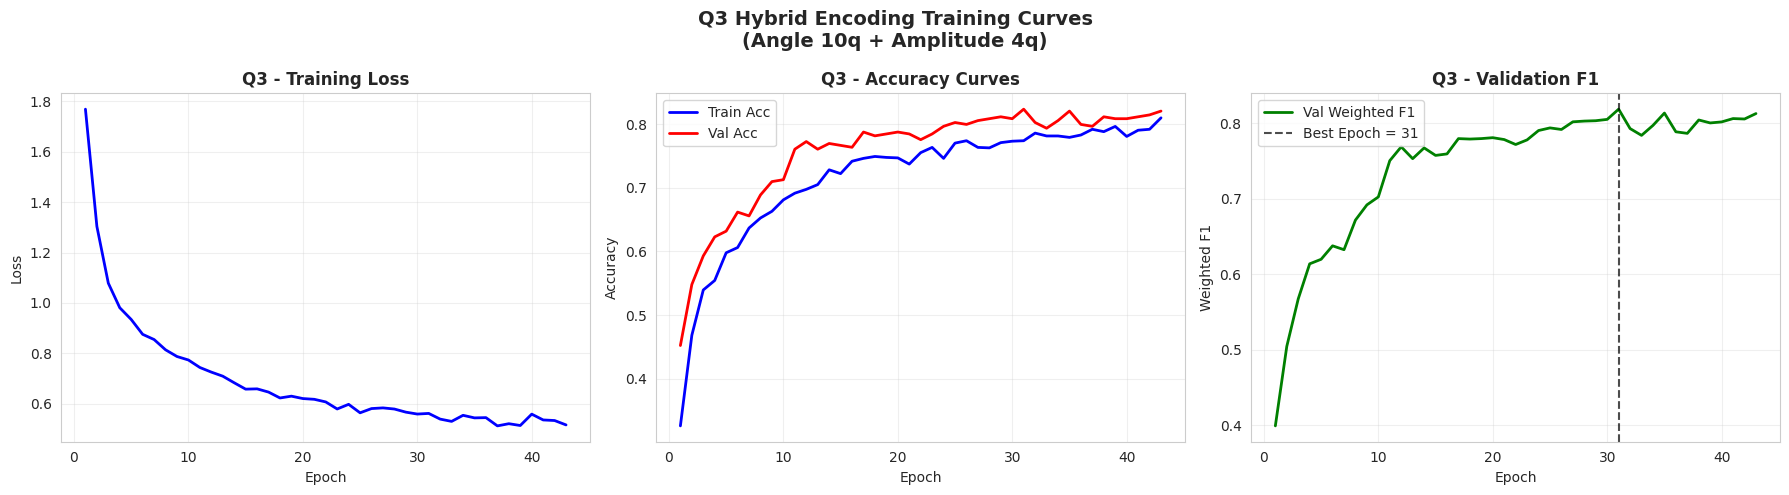

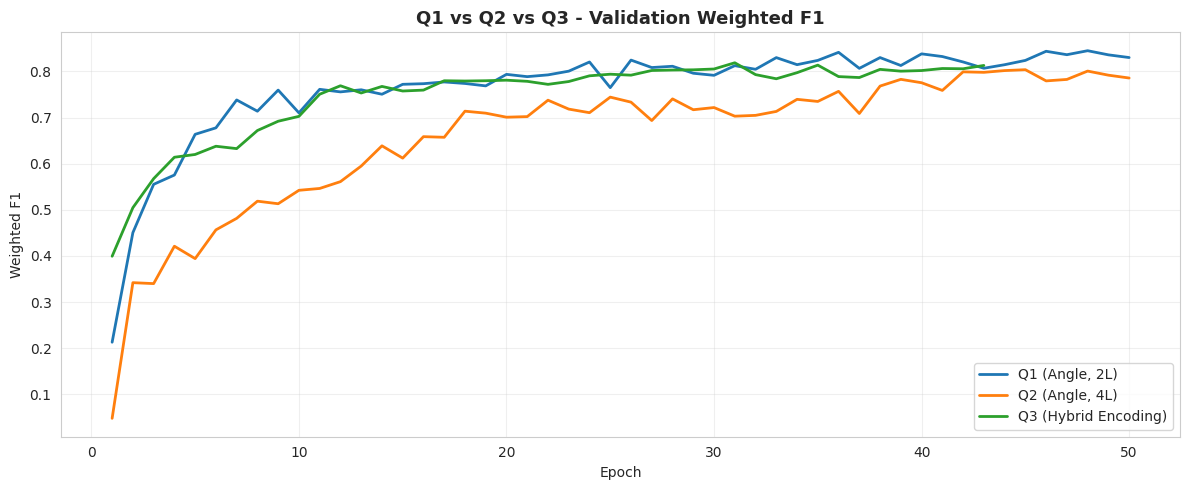

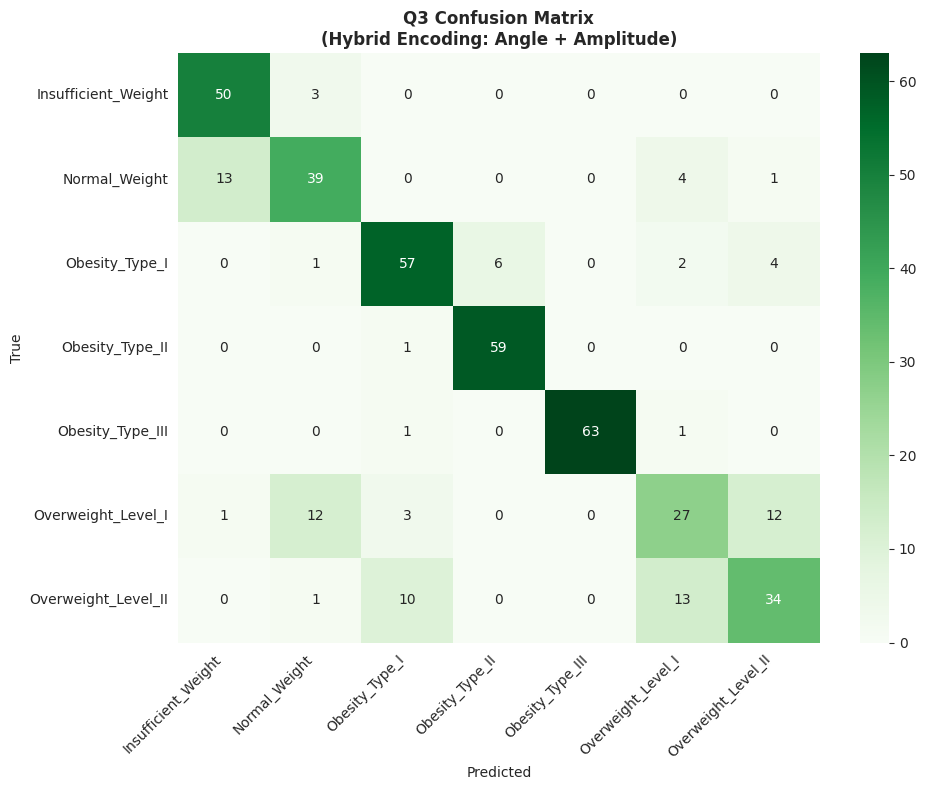

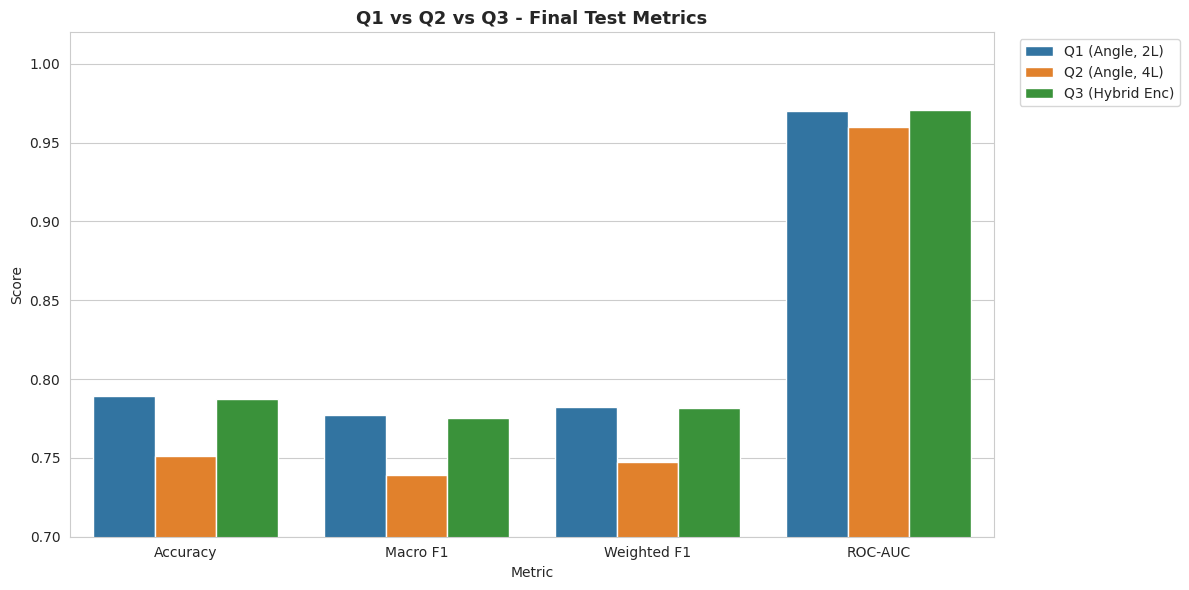

Q3 figürleri kaydedildi:
- q3_training_curves.png
- q1_q2_q3_val_f1_comparison.png
- q3_confusion_matrix.png
- q1_q2_q3_test_metric_barplot.png


In [41]:
# 1) Q3 Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, len(q3_train_losses)+1), q3_train_losses, color='blue', linewidth=2)
axes[0].set_title('Q3 - Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(q3_train_accs)+1), q3_train_accs, label='Train Acc', color='blue', linewidth=2)
axes[1].plot(range(1, len(q3_val_accs)+1), q3_val_accs, label='Val Acc', color='red', linewidth=2)
axes[1].set_title('Q3 - Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, len(q3_val_f1s)+1), q3_val_f1s, label='Val Weighted F1', color='green', linewidth=2)
axes[2].axvline(best_epoch_q3, color='black', linestyle='--', alpha=0.7, label=f'Best Epoch = {best_epoch_q3}')
axes[2].set_title('Q3 - Validation F1', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Weighted F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Q3 Hybrid Encoding Training Curves\n(Angle 10q + Amplitude 4q)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'q3_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# 2) Q1 vs Q2 vs Q3 Validation F1 karsilastirma
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(clean_val_f1s)+1), clean_val_f1s, label='Q1 (Angle, 2L)', linewidth=2)
plt.plot(range(1, len(q2_val_f1s)+1), q2_val_f1s, label='Q2 (Angle, 4L)', linewidth=2)
plt.plot(range(1, len(q3_val_f1s)+1), q3_val_f1s, label='Q3 (Hybrid Encoding)', linewidth=2)
plt.title('Q1 vs Q2 vs Q3 - Validation Weighted F1', fontweight='bold', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Weighted F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'q1_q2_q3_val_f1_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

# 3) Q3 Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_q3_df, annot=True, fmt='d', cmap='Greens')
plt.title('Q3 Confusion Matrix\n(Hybrid Encoding: Angle + Amplitude)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'q3_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# 4) Q1 vs Q2 vs Q3 Test Metric Barplot
metric_all_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC"],
    "Q1 (Angle, 2L)": [acc, f1_mac, f1_w, roc_auc],
    "Q2 (Angle, 4L)": [acc_q2, f1_mac_q2, f1_w_q2, roc_auc_q2],
    "Q3 (Hybrid Enc)": [acc_q3, f1_mac_q3, f1_w_q3, roc_auc_q3]
})

plot_all_df = metric_all_df.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_all_df, x="Metric", y="Score", hue="Model")
plt.ylim(0.7, 1.02)
plt.title('Q1 vs Q2 vs Q3 - Final Test Metrics', fontweight='bold', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'q1_q2_q3_test_metric_barplot.png'), dpi=200, bbox_inches='tight')
plt.show()

print("Q3 figürleri kaydedildi:")
print("- q3_training_curves.png")
print("- q1_q2_q3_val_f1_comparison.png")
print("- q3_confusion_matrix.png")
print("- q1_q2_q3_test_metric_barplot.png")

In [42]:
import pandas as pd
import os

# Klasik modeller
classical_csv_path = '/content/drive/MyDrive/Obesity_Quantum_Project/tables/final_classical_model_comparison_with_xgb.csv'
classical_df = pd.read_csv(classical_csv_path)

# Tum quantum modeller
quantum_all_df = pd.DataFrame([
    {
        "Model": "Hybrid Quantum Q1 (10 özellik, Angle, 2L)",
        "Accuracy": acc,
        "Macro F1": f1_mac,
        "Weighted F1": f1_w
    },
    {
        "Model": "Hybrid Quantum Q2 (10 özellik, Angle, 4L)",
        "Accuracy": acc_q2,
        "Macro F1": f1_mac_q2,
        "Weighted F1": f1_w_q2
    },
    {
        "Model": "Hybrid Quantum Q3 (10 özellik, Angle+Amplitude)",
        "Accuracy": acc_q3,
        "Macro F1": f1_mac_q3,
        "Weighted F1": f1_w_q3
    }
])

# Tam birlesik tablo
full_df = pd.concat([classical_df, quantum_all_df], ignore_index=True)
full_df_sorted = full_df.sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)

# Sadece 10 ozellikli adil karsilastirma
fair_df = pd.concat([
    classical_df[classical_df['Model'].str.contains('10')],
    quantum_all_df
], ignore_index=True)
fair_df_sorted = fair_df.sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)

# Sadece quantum karsilastirma
quantum_only_df = pd.DataFrame([
    {
        "Model": "Q1 - Pure Angle (10q, 2L)",
        "Accuracy": acc,
        "Macro F1": f1_mac,
        "Weighted F1": f1_w,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": roc_auc,
        "Parameters": 335,
        "Best Val F1": best_val_f1,
        "Best Epoch": best_epoch
    },
    {
        "Model": "Q2 - Pure Angle (10q, 4L)",
        "Accuracy": acc_q2,
        "Macro F1": f1_mac_q2,
        "Weighted F1": f1_w_q2,
        "Precision": prec_q2,
        "Recall": rec_q2,
        "ROC-AUC": roc_auc_q2,
        "Parameters": 375,
        "Best Val F1": best_val_f1_q2,
        "Best Epoch": best_epoch_q2
    },
    {
        "Model": "Q3 - Hybrid Encoding (10q+4q, 2L+2L)",
        "Accuracy": acc_q3,
        "Macro F1": f1_mac_q3,
        "Weighted F1": f1_w_q3,
        "Precision": prec_q3,
        "Recall": rec_q3,
        "ROC-AUC": roc_auc_q3,
        "Parameters": 415,
        "Best Val F1": best_val_f1_q3,
        "Best Epoch": best_epoch_q3
    }
])

# Kaydet
full_df_sorted.to_csv(
    os.path.join(q3_tab_dir, 'full_classical_quantum_all_comparison.csv'), index=False)
fair_df_sorted.to_csv(
    os.path.join(q3_tab_dir, 'fair_top10_classical_vs_all_quantum.csv'), index=False)
quantum_only_df.to_csv(
    os.path.join(q3_tab_dir, 'quantum_q1_q2_q3_detailed_comparison.csv'), index=False)

# Ana tables klasorune de kopyala
main_tables_dir = '/content/drive/MyDrive/Obesity_Quantum_Project/tables'
full_df_sorted.to_csv(
    os.path.join(main_tables_dir, 'full_classical_quantum_all_comparison.csv'), index=False)
fair_df_sorted.to_csv(
    os.path.join(main_tables_dir, 'fair_top10_classical_vs_all_quantum.csv'), index=False)
quantum_only_df.to_csv(
    os.path.join(main_tables_dir, 'quantum_q1_q2_q3_detailed_comparison.csv'), index=False)

print("=" * 65)
print("QUANTUM KARSILASTIRMA TABLOSU (Q1 vs Q2 vs Q3)")
print("=" * 65)
print(quantum_only_df[['Model','Accuracy','Macro F1','Weighted F1','ROC-AUC']].round(4).to_string(index=False))

print("\n")
print("=" * 65)
print("ADIL KARSILASTIRMA: 10 OZELLIKLI KLASIK vs QUANTUM")
print("=" * 65)
print(fair_df_sorted.round(4).to_string(index=False))

print("\n")
print("=" * 65)
print("TAM KARSILASTIRMA: TUM MODELLER")
print("=" * 65)
print(full_df_sorted.round(4).to_string(index=False))

QUANTUM KARSILASTIRMA TABLOSU (Q1 vs Q2 vs Q3)
                               Model  Accuracy  Macro F1  Weighted F1  ROC-AUC
           Q1 - Pure Angle (10q, 2L)    0.7895    0.7769       0.7822   0.9698
           Q2 - Pure Angle (10q, 4L)    0.7512    0.7389       0.7473   0.9602
Q3 - Hybrid Encoding (10q+4q, 2L+2L)    0.7871    0.7756       0.7817   0.9705


ADIL KARSILASTIRMA: 10 OZELLIKLI KLASIK vs QUANTUM
                                          Model  Accuracy  Macro F1  Weighted F1
                           XGBoost (10 özellik)    0.9689    0.9681       0.9688
                     Random Forest (10 özellik)    0.9402    0.9381       0.9411
               Logistic Regression (10 özellik)    0.8852    0.8795       0.8843
      Hybrid Quantum Q1 (10 özellik, Angle, 2L)    0.7895    0.7769       0.7822
Hybrid Quantum Q3 (10 özellik, Angle+Amplitude)    0.7871    0.7756       0.7817
      Hybrid Quantum Q2 (10 özellik, Angle, 4L)    0.7512    0.7389       0.7473


TAM KARSILASTIR

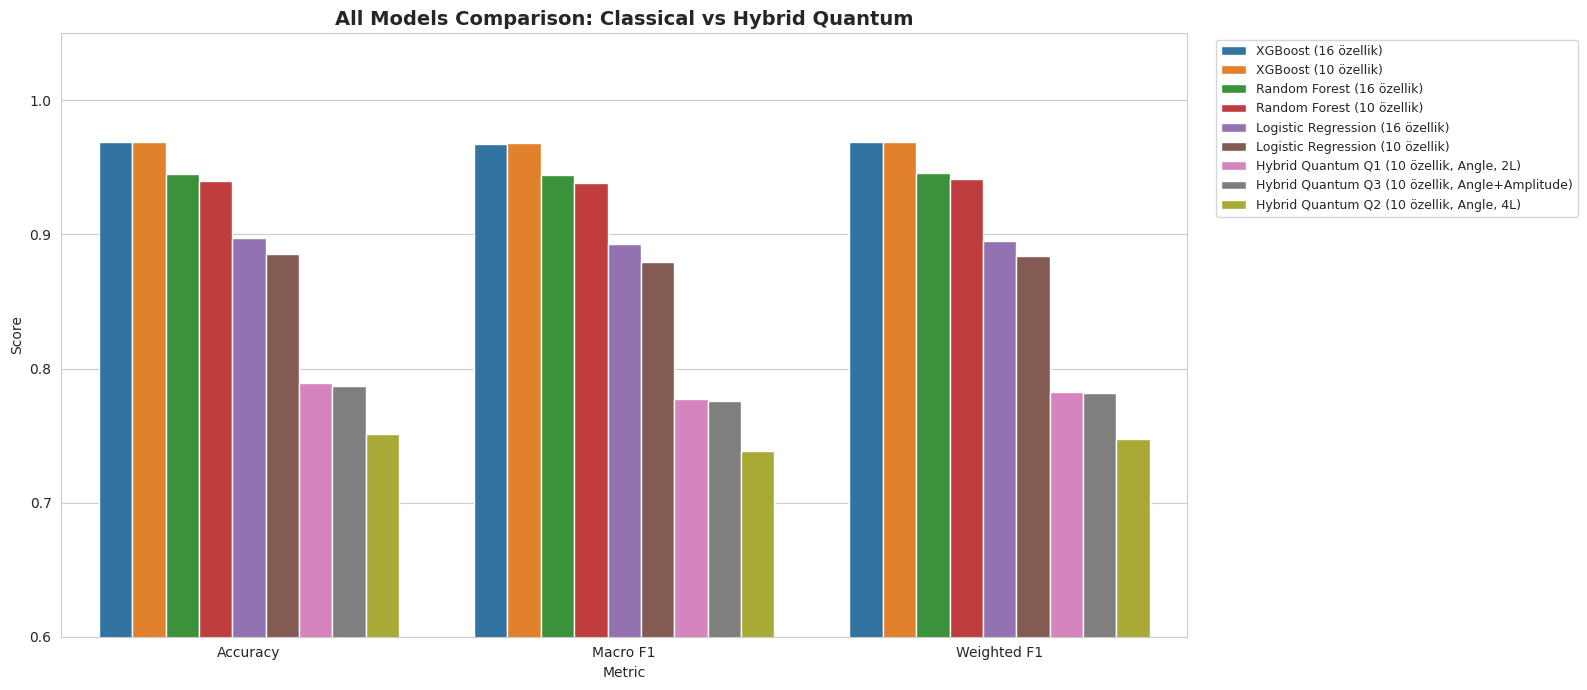

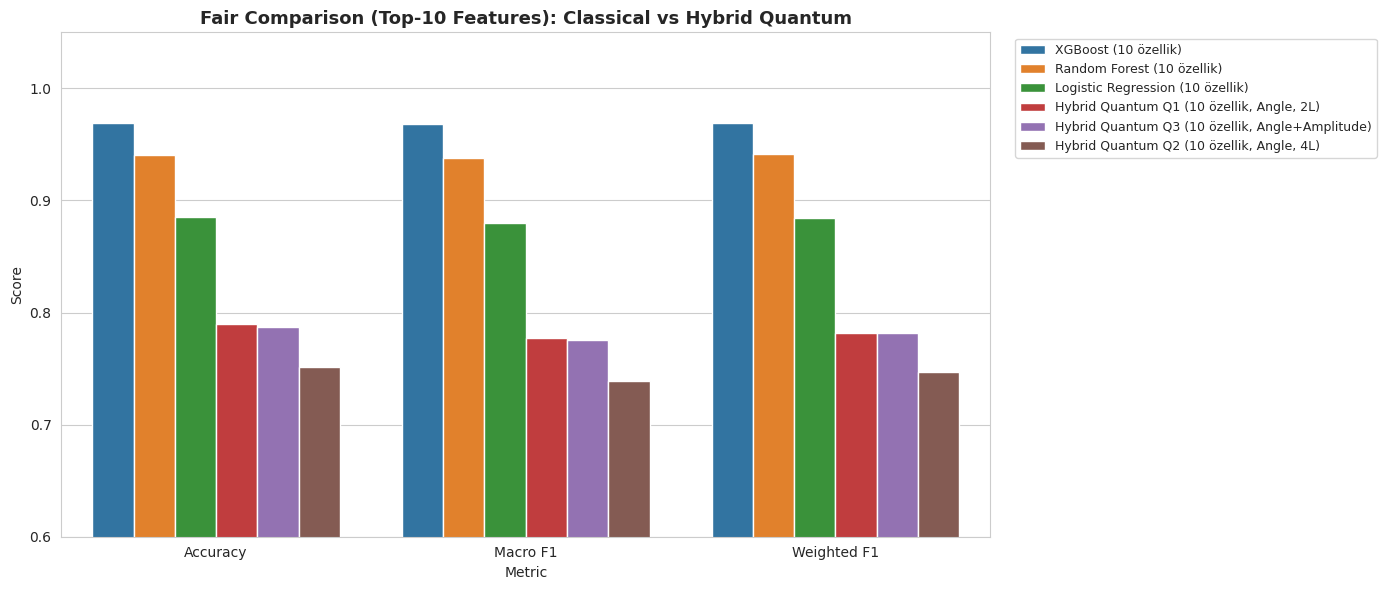

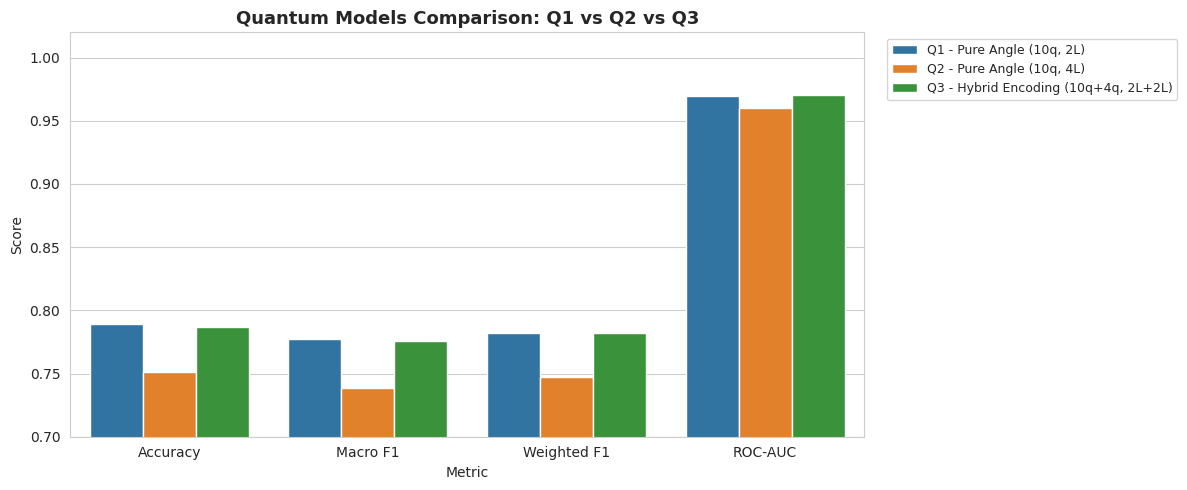

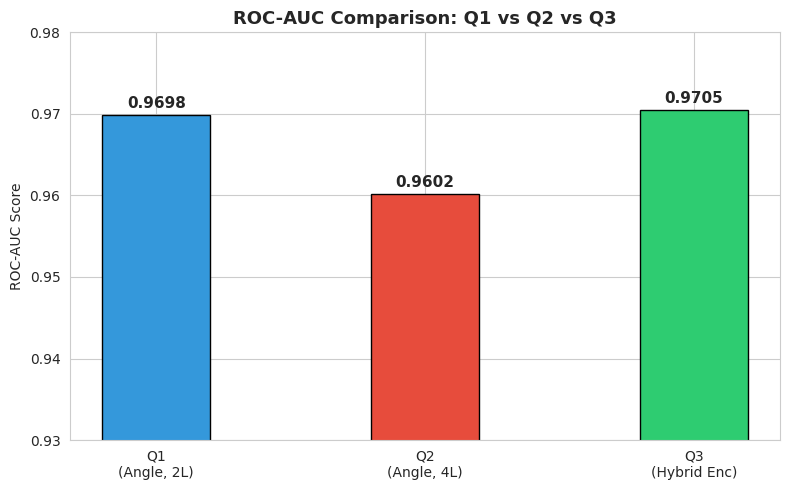

Final figürler kaydedildi:
- full_all_models_barplot.png
- fair_top10_all_models_barplot.png
- quantum_q1_q2_q3_barplot.png
- quantum_roc_auc_comparison.png
- fair_top10_all_models_table.png
- quantum_q1_q2_q3_table.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import os

sns.set_style("whitegrid")

main_figures_dir = '/content/drive/MyDrive/Obesity_Quantum_Project/figures'

# ---- 1) Tam karsilastirma barplot ----
plot_full = full_df_sorted.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Macro F1', 'Weighted F1'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(16, 7))
ax = sns.barplot(data=plot_full, x='Metric', y='Score', hue='Model')
plt.ylim(0.6, 1.05)
plt.title('All Models Comparison: Classical vs Hybrid Quantum',
          fontweight='bold', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'full_all_models_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(main_figures_dir, 'full_all_models_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ---- 2) Adil karsilastirma barplot (10 feature) ----
plot_fair = fair_df_sorted.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Macro F1', 'Weighted F1'],
    var_name='Metric',
    value_name='Score'
)

colors_fair = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c', '#c0392b', '#9b59b6']

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_fair, x='Metric', y='Score', hue='Model')
plt.ylim(0.6, 1.05)
plt.title('Fair Comparison (Top-10 Features): Classical vs Hybrid Quantum',
          fontweight='bold', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'fair_top10_all_models_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(main_figures_dir, 'fair_top10_all_models_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ---- 3) Sadece Quantum karsilastirma ----
quantum_plot_df = quantum_only_df[
    ['Model', 'Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']
].melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 5))
sns.barplot(data=quantum_plot_df, x='Metric', y='Score', hue='Model')
plt.ylim(0.7, 1.02)
plt.title('Quantum Models Comparison: Q1 vs Q2 vs Q3',
          fontweight='bold', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'quantum_q1_q2_q3_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(main_figures_dir, 'quantum_q1_q2_q3_barplot.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ---- 4) ROC-AUC quantum karsilastirma ----
models_roc = ['Q1\n(Angle, 2L)', 'Q2\n(Angle, 4L)', 'Q3\n(Hybrid Enc)']
roc_values = [roc_auc, roc_auc_q2, roc_auc_q3]
colors_roc = ['#3498db', '#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_roc, roc_values, color=colors_roc, width=0.4, edgecolor='black')
plt.ylim(0.93, 0.98)
for bar, val in zip(bars, roc_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0005,
             f'{val:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.title('ROC-AUC Comparison: Q1 vs Q2 vs Q3',
          fontweight='bold', fontsize=13)
plt.ylabel('ROC-AUC Score')
plt.tight_layout()
plt.savefig(os.path.join(q3_fig_dir, 'quantum_roc_auc_comparison.png'),
            dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(main_figures_dir, 'quantum_roc_auc_comparison.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ---- 5) Tablo gorseli - Adil karsilastirma ----
def save_df_as_image(df, title, save_path):
    df_show = df.copy()
    for col in df_show.columns:
        if pd.api.types.is_float_dtype(df_show[col]):
            df_show[col] = df_show[col].map(lambda x: f"{x:.4f}")
    fig_w = max(12, len(df_show.columns) * 2.5)
    fig_h = max(3, len(df_show) * 0.65 + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    table = ax.table(cellText=df_show.values,
                     colLabels=df_show.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)
    plt.title(title, fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()

save_df_as_image(
    fair_df_sorted,
    'Fair Comparison (10 Features): Classical vs Hybrid Quantum',
    os.path.join(q3_fig_dir, 'fair_top10_all_models_table.png')
)
save_df_as_image(
    fair_df_sorted,
    'Fair Comparison (10 Features): Classical vs Hybrid Quantum',
    os.path.join(main_figures_dir, 'fair_top10_all_models_table.png')
)

save_df_as_image(
    quantum_only_df[['Model','Accuracy','Macro F1','Weighted F1','ROC-AUC','Parameters']],
    'Quantum Models Detailed Comparison: Q1 vs Q2 vs Q3',
    os.path.join(q3_fig_dir, 'quantum_q1_q2_q3_table.png')
)
save_df_as_image(
    quantum_only_df[['Model','Accuracy','Macro F1','Weighted F1','ROC-AUC','Parameters']],
    'Quantum Models Detailed Comparison: Q1 vs Q2 vs Q3',
    os.path.join(main_figures_dir, 'quantum_q1_q2_q3_table.png')
)

print("Final figürler kaydedildi:")
print("- full_all_models_barplot.png")
print("- fair_top10_all_models_barplot.png")
print("- quantum_q1_q2_q3_barplot.png")
print("- quantum_roc_auc_comparison.png")
print("- fair_top10_all_models_table.png")
print("- quantum_q1_q2_q3_table.png")

In [44]:
import json

q3_params = sum(p.numel() for p in model_q3.parameters())

q3_metadata = {
    "experiment_name": "quantum_clean_top10_hybrid_encoding",
    "description": "Hybrid angle+amplitude encoding quantum model (Q3)",
    "dataset": {
        "train_file": "train_10_features.csv",
        "test_file": "test_10_features.csv",
        "n_features": 10,
        "n_classes": 7,
        "class_names": list(le.classes_)
    },
    "splits": {
        "train": 1335,
        "validation": 334,
        "test": 418,
        "note": "Q1/Q2 ile birebir ayni split. random_state=42, stratified."
    },
    "architecture": {
        "angle_branch": {
            "qubits": 10,
            "layers": 2,
            "encoding": "AngleEmbedding RY",
            "entanglement": "Ring CNOT",
            "readout": "PauliZ all qubits",
            "output_dim": 10
        },
        "amplitude_branch": {
            "qubits": 4,
            "layers": 2,
            "encoding": "AmplitudeEmbedding (pad to 16, L2 normalize)",
            "entanglement": "Ring CNOT",
            "readout": "PauliZ all qubits",
            "output_dim": 4
        },
        "fusion": "concatenate angle(10) + amplitude(4) = 14 dim",
        "classical_head": "Linear(14,16) + ReLU + Dropout(0.2) + Linear(16,7)",
        "total_parameters": int(q3_params)
    },
    "training": {
        "optimizer": "Adam",
        "lr": 0.01,
        "batch_size": 32,
        "max_epochs": 50,
        "early_stopping_patience": 12,
        "loss": "CrossEntropyLoss",
        "seed": 42,
        "actual_epochs_trained": len(q3_train_losses),
        "best_epoch": int(best_epoch_q3)
    },
    "results": {
        "best_val_f1": float(best_val_f1_q3),
        "test_accuracy": float(acc_q3),
        "test_macro_f1": float(f1_mac_q3),
        "test_weighted_f1": float(f1_w_q3),
        "test_precision": float(prec_q3),
        "test_recall": float(rec_q3),
        "test_roc_auc": float(roc_auc_q3)
    }
}

with open(os.path.join(q3_note_dir, 'q3_experiment_metadata.json'),
          'w', encoding='utf-8') as f:
    json.dump(q3_metadata, f, ensure_ascii=False, indent=4)

summary_q3 = f"""
Q3 EXPERIMENT SUMMARY
=====================

Experiment: quantum_clean_top10_hybrid_encoding

Model: Hybrid Encoding Q3
- Angle Branch  : 10 qubits, 2 layers, AngleEmbedding RY, Ring CNOT
- Amplitude Branch: 4 qubits, 2 layers, AmplitudeEmbedding, Ring CNOT
- Fusion        : concat(angle_out[10], amp_out[4]) = 14 dim
- Classical Head: Linear(14,16) -> ReLU -> Dropout(0.2) -> Linear(16,7)
- Total Params  : {q3_params}

Split (same as Q1/Q2):
- Train     : 1335
- Validation: 334
- Test      : 418

Training:
- Optimizer : Adam (lr=0.01)
- Batch size: 32
- Max epochs: 50
- Early stop: patience=12
- Trained   : {len(q3_train_losses)} epochs
- Best epoch: {best_epoch_q3}

Results:
- Best Val F1   : {best_val_f1_q3:.4f}
- Test Accuracy : {acc_q3:.4f}
- Test Macro F1 : {f1_mac_q3:.4f}
- Test Wtd F1   : {f1_w_q3:.4f}
- Test Precision: {prec_q3:.4f}
- Test Recall   : {rec_q3:.4f}
- Test ROC-AUC  : {roc_auc_q3:.4f}

Comparison with Q1 and Q2:
- Q1 (Pure Angle, 2L) : Acc={acc:.4f} | Wtd F1={f1_w:.4f} | ROC-AUC={roc_auc:.4f}
- Q2 (Pure Angle, 4L) : Acc={acc_q2:.4f} | Wtd F1={f1_w_q2:.4f} | ROC-AUC={roc_auc_q2:.4f}
- Q3 (Hybrid Enc)     : Acc={acc_q3:.4f} | Wtd F1={f1_w_q3:.4f} | ROC-AUC={roc_auc_q3:.4f}

Key Findings:
1. Q1 en yuksek Accuracy ve F1 weighted elde etti.
2. Q3 en yuksek ROC-AUC degerini elde etti (0.9705).
3. Q1 vs Q3 farki son derece kucuk:
   - Accuracy farki  : {abs(acc - acc_q3):.4f}
   - Wtd F1 farki    : {abs(f1_w - f1_w_q3):.4f}
   - ROC-AUC farki   : {abs(roc_auc - roc_auc_q3):.4f}
4. Q2 (derin devre) her metrikte geride kaldi.
5. Amplitude encoding eklenmesi ROC-AUC'yi artirdi
   ama overall F1 ve accuracy'de Q1 one gecemedi.
6. Hibrit encoding erken durdu (epoch {len(q3_train_losses)}),
   pure angle Q1 tum 50 epoch boyunca ilerledi.
"""

with open(os.path.join(q3_note_dir, 'q3_experiment_summary.txt'),
          'w', encoding='utf-8') as f:
    f.write(summary_q3)

print("Q3 notlari kaydedildi:")
print("- q3_experiment_metadata.json")
print("- q3_experiment_summary.txt")
print()
print(summary_q3)

Q3 notlari kaydedildi:
- q3_experiment_metadata.json
- q3_experiment_summary.txt


Q3 EXPERIMENT SUMMARY

Experiment: quantum_clean_top10_hybrid_encoding

Model: Hybrid Encoding Q3
- Angle Branch  : 10 qubits, 2 layers, AngleEmbedding RY, Ring CNOT
- Amplitude Branch: 4 qubits, 2 layers, AmplitudeEmbedding, Ring CNOT
- Fusion        : concat(angle_out[10], amp_out[4]) = 14 dim
- Classical Head: Linear(14,16) -> ReLU -> Dropout(0.2) -> Linear(16,7)
- Total Params  : 415

Split (same as Q1/Q2):
- Train     : 1335
- Validation: 334
- Test      : 418

Training:
- Optimizer : Adam (lr=0.01)
- Batch size: 32
- Max epochs: 50
- Early stop: patience=12
- Trained   : 43 epochs
- Best epoch: 31

Results:
- Best Val F1   : 0.8187
- Test Accuracy : 0.7871
- Test Macro F1 : 0.7756
- Test Wtd F1   : 0.7817
- Test Precision: 0.7805
- Test Recall   : 0.7871
- Test ROC-AUC  : 0.9705

Comparison with Q1 and Q2:
- Q1 (Pure Angle, 2L) : Acc=0.7895 | Wtd F1=0.7822 | ROC-AUC=0.9698
- Q2 (Pure Angle, 4L) : A